In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
import itertools

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from scipy.stats import mannwhitneyu
from itertools import combinations

from collections import defaultdict
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import euclidean
import matplotlib.lines as mlines

from scipy.linalg import eigvalsh

from matplotlib.lines import Line2D

sc.settings.verbosity = 2

# Load in data

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.42 GB, difference +2.42 GB
CPU times: user 231 ms, sys: 1.46 s, total: 1.69 s
Wall time: 4.45 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Load in gene sets

In [3]:
# TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639


In [4]:
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(len(regev_genes))


cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(len(cc_genes))

97
142


In [5]:
# MYOD/PRRX1 targets and influencers from the HWG

path1 = "../../resources/HWG_MYOD_Influencers.csv"
path2 = "../../resources/HWG_MYOD_Target.csv"
path3 = "../../resources/HWG_PRRX1_Influencers.csv"
path4 = "../../resources/HWG_PRRX1_Target.csv"

def load_and_rename(path, gene, role):
    df = pd.read_csv(path)
    df = df.rename(columns={
        f"{gene} {role}": "gene",
        f"{gene} {role} ID": "gene_id",
        f"{gene} {role} degree centrality": "degree_centrality",
        f"{gene} {role} Eigenvector centrality": "eigenvector_centrality"
    })
    return df

myod_inf = load_and_rename(path1, "MYOD", "Influencer")
myod_tar = load_and_rename(path2, "MYOD", "Target")
prrx_inf = load_and_rename(path3, "PRRX1", "Influencer")
prrx_tar = load_and_rename(path4, "PRRX1", "Target")

for name, df in zip(
    ["MYOD Influencers", "MYOD Targets", "PRRX1 Influencers", "PRRX1 Targets"],
    [myod_inf, myod_tar, prrx_inf, prrx_tar]
):
    print(f"{name}: {df['gene'].nunique()} unique genes ({df.shape[0]} rows)")

MYOD Influencers: 170 unique genes (170 rows)
MYOD Targets: 544 unique genes (544 rows)
PRRX1 Influencers: 78 unique genes (78 rows)
PRRX1 Targets: 195 unique genes (195 rows)


In [11]:
myod_inf.head()

,gene,gene_id,degree_centrality,eigenvector_centrality
0,TP53,ENSG00000141510,0.171,0.079
1,MYC,ENSG00000136997,0.140,0.073
2,STAT3,ENSG00000168610,0.093,0.051
3,JUN,ENSG00000177606,0.090,0.051
4,NFKB1,ENSG00000109320,0.080,0.049


In [6]:
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in adata.var_names]
print(f"N fib genes in adata: {len(fib_genes)}")


myo_genes = (panglao_markers['Myocytes'] == True) | (panglao_markers['Myoblasts'] == True)
myo_genes =  panglao_markers[myo_genes].index
myo_genes = [g for g in myo_genes if g in adata.var_names]
print(f"N myocyte/myoblast genes in adata: {len(myo_genes)}")

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563
N fib genes in adata: 220
N myocyte/myoblast genes in adata: 210


# Scree plots

Data shape: (6960, 220)
computing PCA
    with n_comps=50


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:00)


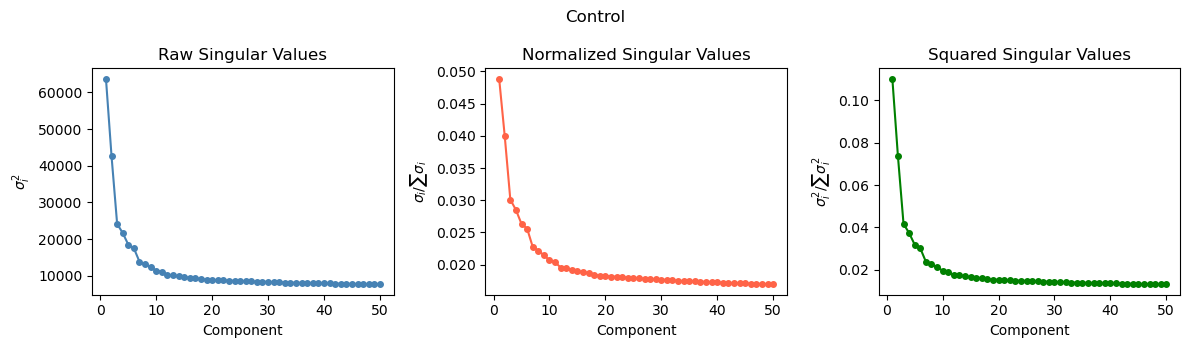

Data shape: (2109, 220)
computing PCA
    with n_comps=50
    finished (0:00:00)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


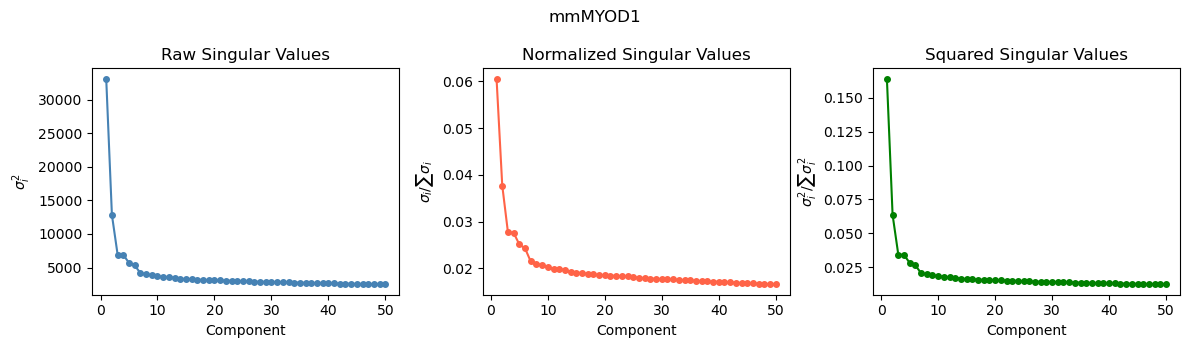

Data shape: (3451, 220)
computing PCA
    with n_comps=50
    finished (0:00:00)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


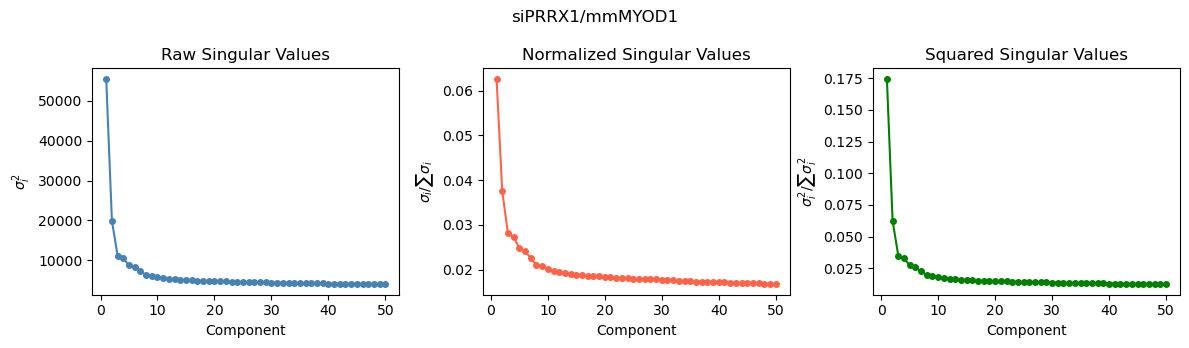

Data shape: (3430, 220)
computing PCA
    with n_comps=50
    finished (0:00:00)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


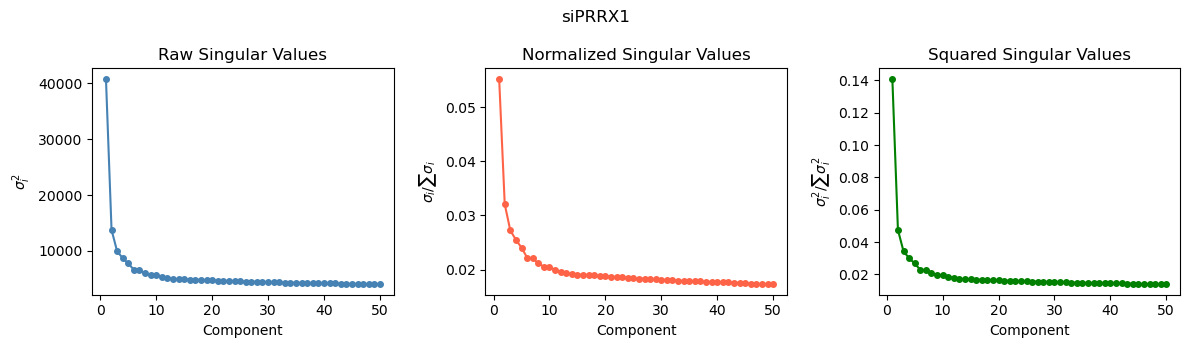

In [61]:
# gene_list = fib_genes.copy()
# gene_list = [g for g in gene_list if g in adata.var_names]

# cdata = adata[:, gene_list].copy()

# cond_order = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1']


# for cond in cond_order:
    
#     bdata = cdata[cdata.obs['pooled_condition'] == cond, :].copy()

#     print(f"Data shape: {bdata.shape}")
#     bdata.X = bdata.layers['log_norm'].copy()

#     sc.pp.scale(bdata) # zero mean, unit variance

#     # computes SVD of the scaled matrix: U∑V^T
#     sc.pp.pca(
#         bdata,
#         n_comps=50,
#         mask_var=None,
#     )

#     # Extract singular values (stored as square root of variance)
#     n_cells = bdata.n_obs

#     singular_values = np.sqrt(bdata.uns['pca']['variance'] * (n_cells - 1))
#     normalized_sv = singular_values / singular_values.sum()

#     singular_values_squared = bdata.uns['pca']['variance'] * (n_cells - 1)
#     normalized_sv_squared = singular_values_squared / singular_values_squared.sum()

#     n_pcs = len(singular_values)

#     # Plot
#     fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3.5))

#     # Raw singular values
#     # ax1.plot(range(1, n_pcs + 1), singular_values, marker='o', markersize=4, color='steelblue')
#     ax1.plot(range(1, n_pcs + 1), singular_values_squared, marker='o', markersize=4, color='steelblue')
#     ax1.set_xlabel('Component')
#     # ax1.set_ylabel('Singular Value')
#     ax1.set_ylabel('$σ_i^2$')
#     ax1.set_title('Raw Singular Values')

#     # Normalized singular values
#     ax2.plot(range(1, n_pcs + 1), normalized_sv, marker='o', markersize=4, color='tomato')
#     ax2.set_xlabel('Component')
#     # ax2.set_ylabel('Normalized Singular Value')
#     ax2.set_ylabel('$σ_i$/∑$σ_i$')
#     ax2.set_title('Normalized Singular Values')

#     # Normalized singular values ^ 2
#     ax3.plot(range(1, n_pcs + 1), normalized_sv_squared, marker='o', markersize=4, color='g')
#     ax3.set_xlabel('Component')
#     # ax3.set_ylabel('Normalized Singular Value')
#     ax3.set_ylabel('$σ_i^2$/∑$σ_i^2$')
#     ax3.set_title('Squared Singular Values')

#     plt.suptitle(f"{cond}")
    
#     plt.tight_layout()
#     plt.show()
    
    
#     # break

In [33]:
myod_tar.head()

,gene,gene_id,degree_centrality,eigenvector_centrality
0,GAPDH,ENSG00000111640,0.180,0.086
1,TP53,ENSG00000141510,0.171,0.079
2,ACTB,ENSG00000075624,0.151,0.074
3,MYC,ENSG00000136997,0.140,0.073
4,AKT1,ENSG00000142208,0.146,0.065


Data shape: (6902, 120)
computing PCA
    with n_comps=50
    finished (0:00:00)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Data shape: (2255, 120)
computing PCA
    with n_comps=50
    finished (0:00:00)
Data shape: (3456, 120)
computing PCA
    with n_comps=50


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:00)
Data shape: (3683, 120)
computing PCA
    with n_comps=50
    finished (0:00:00)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


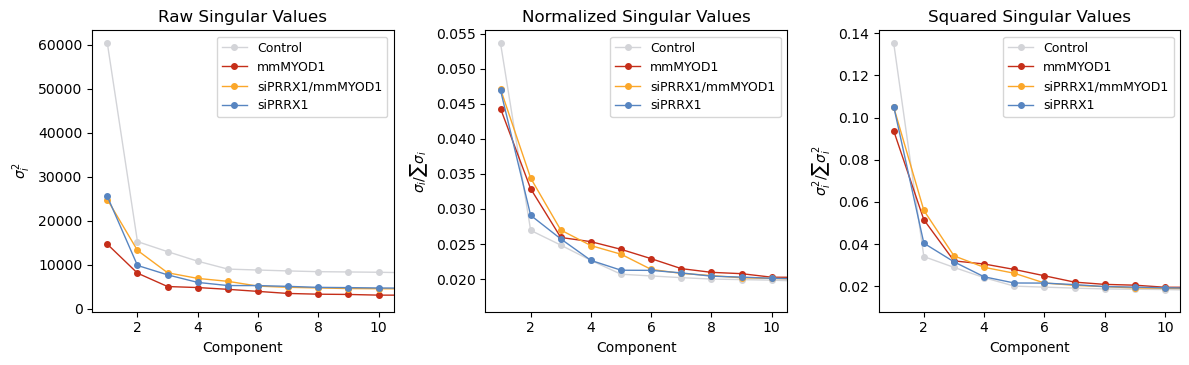

In [27]:
# single plot

# gene_list = fib_genes.copy()
# gene_list = tf_list.copy()
# gene_list = regev_genes.copy()
gene_list = cc_genes.copy()
# gene_list = myod_tar['gene'].unique()
# gene_list = prrx_tar['gene'].unique()
# gene_list = myod_inf['gene'].unique()

gene_list = [g for g in gene_list if g in adata.var_names]
cdata = adata[:, gene_list].copy()
cond_order = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1']

# Store results in a dict
results = {}

for cond in cond_order:
    bdata = cdata[cdata.obs['pooled_condition'] == cond, :].copy()
    print(f"Data shape: {bdata.shape}")
    
    bdata.X = bdata.layers['log_norm'].copy()
    sc.pp.scale(bdata) # zero mean, unit variance
    sc.pp.pca(bdata, n_comps=50, mask_var=None)  # computes SVD of the scaled matrix: U∑V^T
    
     # Extract singular values (stored as square root of variance)
    n_cells = bdata.n_obs
    singular_values_squared = bdata.uns['pca']['variance'] * (n_cells - 1)
    singular_values = np.sqrt(singular_values_squared)
    
    # Extract loadings (top contributing genes)
    n_top_pcs = 5
    loadings = bdata.varm['PCs'][:, :n_top_pcs] # shape: (n_genes, n_top_pcs)
    loadings_df = pd.DataFrame(
        loadings,
        index=bdata.var_names,
        columns=[f'PC{i+1}' for i in range(n_top_pcs)]
    )
    
    # sc.pl.pca_loadings(bdata, components=(1, 2, 3), n_points=10)
    
    results[cond] = {
        'singular_values': singular_values,
        'normalized_sv': singular_values / singular_values.sum(),
        'singular_values_squared': singular_values_squared,
        'normalized_sv_squared': singular_values_squared / singular_values_squared.sum(),
        'n_pcs': len(singular_values),
        'loadings': loadings_df,
    }
    
    
fig, axes = plt.subplots(1, 3, figsize=(12, 3.75))

plot_configs = [
    ('singular_values_squared', '$σ_i^2$',          'Raw Singular Values'),
    ('normalized_sv',           '$σ_i$/∑$σ_i$',     'Normalized Singular Values'),
    ('normalized_sv_squared',   '$σ_i^2$/∑$σ_i^2$', 'Squared Singular Values'),
]

# colors = {'Control': 'tab:blue', 'mmMYOD1': 'tab:orange', 'siPRRX1/mmMYOD1': 'tab:green', 'siPRRX1': 'tab:red'}
colors = {'Control': '#D3D4D8', 'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A', 'siPRRX1': '#5785C1'}

for col, (key, ylabel, title) in enumerate(plot_configs):
    ax = axes[col]
    for cond in cond_order:
        n_pcs = results[cond]['n_pcs']
        ax.plot(range(1, n_pcs + 1), results[cond][key],
                marker='o', markersize=4, linewidth=1,
                color=colors[cond], label=cond)
    ax.set_xlabel('Component')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    # ax.set_xlim(right=10)
    ax.set_xlim([0.5, 10.5])
    
    # ax.set_ylim(bottom=0)
# axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
# plt.suptitle(f'Fibroblast genes ({len(gene_list)} genes)')
plt.tight_layout()
plt.show()

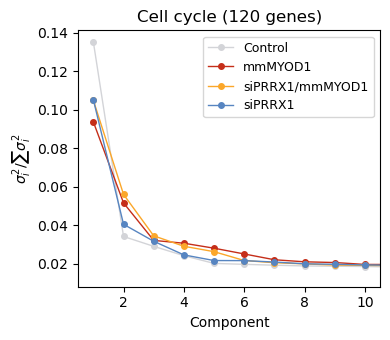

In [28]:
fig, ax = plt.subplots(figsize=(4, 3.5))

for cond in cond_order:
    n_pcs = results[cond]['n_pcs']
    ax.plot(range(1, n_pcs + 1), results[cond]['normalized_sv_squared'],
            marker='o', markersize=4, linewidth=1,
            color=colors[cond], label=cond)

ax.set_xlabel('Component')
ax.set_ylabel('$σ_i^2$/∑$σ_i^2$')
# ax.set_title(f'Normalized Singular Values\nFibroblast genes ({len(gene_list)} genes)')
# ax.set_title(f'Fibroblast genes ({len(gene_list)} genes)')
# ax.set_title(f'TFs ({len(gene_list)} genes)')
# ax.set_title(f'PRRX1 targets ({len(gene_list)} genes)')
# ax.set_title(f'MYOD1 influencers ({len(gene_list)} genes)')
# ax.set_title(f'MYOD1 targets ({len(gene_list)} genes)')
ax.set_title(f'Cell cycle ({len(gene_list)} genes)')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0.5, 10.5])

plt.tight_layout()
plt.show()

In [53]:
cond = 'mmMYOD1'
pc = 'PC1'

results[cond]['loadings'][pc].abs().sort_values(ascending=False).head(10)

gene_name
CCNA2    0.244224
HSPA8    0.241072
CDK1     0.227454
CCNB1    0.216670
PLK2     0.210282
AURKA    0.190250
MASTL    0.189054
RPS6     0.186073
CDKN3    0.182355
MELK     0.181959
Name: PC1, dtype: float64

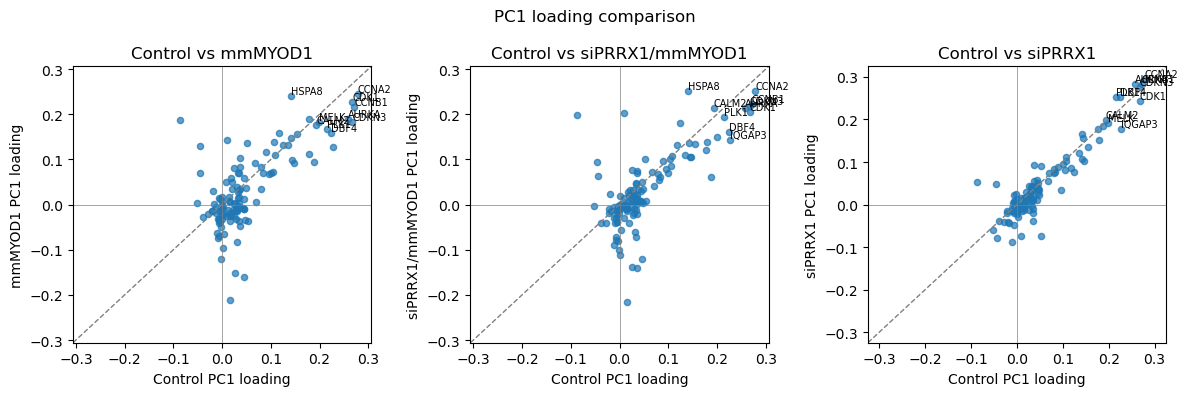

In [54]:
import itertools

pc = 'PC1'
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Compare all pairs of conditions
pairs = list(itertools.combinations(cond_order, 2))

for ax, (cond1, cond2) in zip(axes, pairs):
    df1 = results[cond1]['loadings'][pc]
    df2 = results[cond2]['loadings'][pc]
    
    ax.scatter(df1, df2, s=20, alpha=0.7)
    
    # Label top genes by absolute loading in either condition
    top_genes = (df1.abs() + df2.abs()).sort_values(ascending=False).head(10).index
    for gene in top_genes:
        ax.annotate(gene, (df1[gene], df2[gene]), fontsize=7, ha='left', va='bottom')
    
    # Add diagonal reference line
    lim = max(abs(df1).max(), abs(df2).max()) * 1.1
    ax.axline((0, 0), slope=1, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    
    ax.set_xlabel(f'{cond1} {pc} loading')
    ax.set_ylabel(f'{cond2} {pc} loading')
    ax.set_title(f'{cond1} vs {cond2}')

plt.suptitle(f'PC1 loading comparison')
plt.tight_layout()
plt.show()

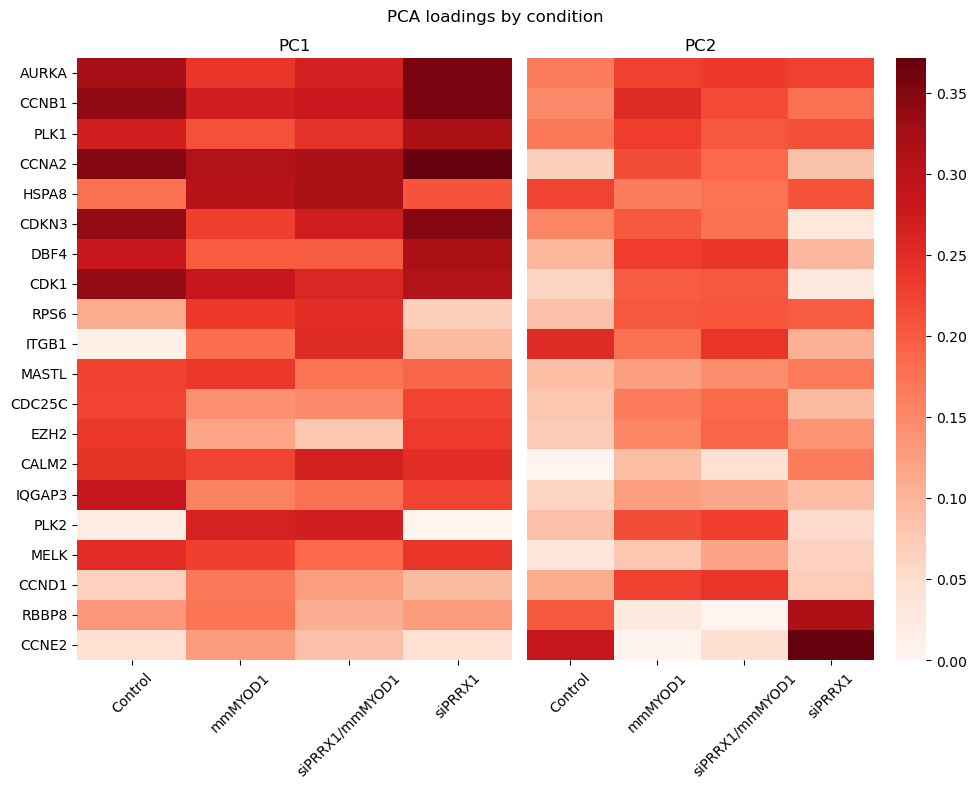

In [63]:
n_pcs = 2
pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

# Build a combined dataframe: for each gene, get absolute loadings per condition per PC
# MultiIndex columns: (condition, PC)
dfs = []
for cond in cond_order:
    df = results[cond]['loadings'][pc_cols].abs()
    df.columns = pd.MultiIndex.from_tuples([(cond, pc) for pc in pc_cols])
    dfs.append(df)

combined = pd.concat(dfs, axis=1)  # shape: (n_genes, n_conditions * n_pcs)

# Optionally sort genes by their mean loading across all conditions/PCs
combined = combined.loc[combined.mean(axis=1).sort_values(ascending=False).index]

combined = combined.iloc[:20]

fig, axes = plt.subplots(1, n_pcs, figsize=(10, 8))  # no sharey

for col, pc in enumerate(pc_cols):
    ax = axes[col]
    pc_data = combined.xs(pc, axis=1, level=1)
    sns.heatmap(
        pc_data,
        ax=ax,
        cmap='Reds',
        vmin=0,
        yticklabels=(col == 0),
        cbar=(col == n_pcs - 1),
        xticklabels=True,
    )
    ax.set_title(pc)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
    if col != 0:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', left=False)

plt.suptitle('PCA loadings by condition')
plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(1, n_pcs, figsize=(10, 5), sharey=True)

# for col, pc in enumerate(pc_cols):
#     ax = axes[col]
#     pc_data = combined.xs(pc, axis=1, level=1)  # shape: (n_genes, n_conditions)
#     sns.heatmap(
#         pc_data,
#         ax=ax,
#         cmap='Reds',
#         vmin=0,
#         yticklabels=True,
#         # yticklabels=(col == 0),
#         cbar=(col == n_pcs - 1),
#         xticklabels=True,
#     )
#     ax.set_title(pc)
#     ax.set_xlabel('')
#     ax.set_ylabel('')
#     ax.tick_params(axis='x', rotation=45)

#     if col == 0:
#         ax.set_yticks(range(len(combined)))
#         ax.set_yticklabels(combined.index.tolist(), fontsize=8)
    
#     if col != 0:
#         ax.set_yticklabels([])
#         ax.tick_params(axis='y', left=False)
        
# plt.suptitle('PCA loadings by condition')
# plt.tight_layout()
# plt.show()

In [59]:
print(combined.index.tolist())
print(combined.shape)

['CCNB1', 'AURKA', 'PLK1', 'CDKN3', 'CDK1', 'RPS6', 'CCNE2', 'HSPA8', 'CCNA2', 'RBBP8', 'MASTL', 'ITGB1', 'DBF4', 'PKMYT1', 'APP', 'CALM2', 'EZH2', 'MELK', 'CDC25C', 'CALM1']
(20, 12)


extracting highly variable genes
    finished (0:00:02)
Number of HVG: 2000
Data shape: (6902, 25126)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:04)
Data shape: (2255, 25126)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:00)
Data shape: (3456, 25126)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:01)
Data shape: (3683, 25126)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:01)


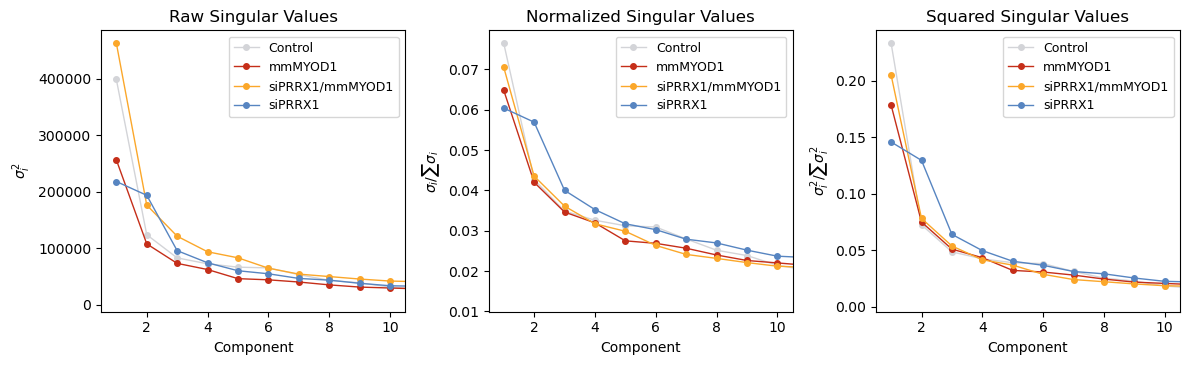

In [23]:
# HVGs

cond_order = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1']

# get HVGs
adata.X = adata.layers['log_norm'].copy()

sc.pp.highly_variable_genes(
    adata,
    batch_key='dataset',
    n_top_genes=2000,
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")


# Store results in a dict
results = {}

for cond in cond_order:
    bdata = adata[adata.obs['pooled_condition'] == cond, :].copy()
    print(f"Data shape: {bdata.shape}")
    
    bdata.X = bdata.layers['log_norm'].copy()
    sc.pp.scale(bdata) # zero mean, unit variance
    sc.pp.pca(bdata, n_comps=50, mask_var='highly_variable')  # computes SVD of the scaled matrix: U∑V^T
    
    # sc.pl.pca_loadings(bdata, components=(1, 2, 3), n_points=10)
    
     # Extract singular values (stored as square root of variance)
    n_cells = bdata.n_obs
    singular_values_squared = bdata.uns['pca']['variance'] * (n_cells - 1)
    singular_values = np.sqrt(singular_values_squared)
    
    results[cond] = {
        'singular_values': singular_values,
        'normalized_sv': singular_values / singular_values.sum(),
        'singular_values_squared': singular_values_squared,
        'normalized_sv_squared': singular_values_squared / singular_values_squared.sum(),
        'n_pcs': len(singular_values),
    }
    
    
fig, axes = plt.subplots(1, 3, figsize=(12, 3.75))

plot_configs = [
    ('singular_values_squared', '$σ_i^2$',          'Raw Singular Values'),
    ('normalized_sv',           '$σ_i$/∑$σ_i$',     'Normalized Singular Values'),
    ('normalized_sv_squared',   '$σ_i^2$/∑$σ_i^2$', 'Squared Singular Values'),
]

# colors = {'Control': 'tab:blue', 'mmMYOD1': 'tab:orange', 'siPRRX1/mmMYOD1': 'tab:green', 'siPRRX1': 'tab:red'}
colors = {'Control': '#D3D4D8', 'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A', 'siPRRX1': '#5785C1'}

for col, (key, ylabel, title) in enumerate(plot_configs):
    ax = axes[col]
    for cond in cond_order:
        n_pcs = results[cond]['n_pcs']
        ax.plot(range(1, n_pcs + 1), results[cond][key],
                marker='o', markersize=4, linewidth=1,
                color=colors[cond], label=cond)
    ax.set_xlabel('Component')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    # ax.set_xlim(right=10)
    ax.set_xlim([0.5, 10.5])
    
    # ax.set_ylim(bottom=0)
# axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
# plt.suptitle(f'Fibroblast genes ({len(gene_list)} genes)')
plt.tight_layout()
plt.show()

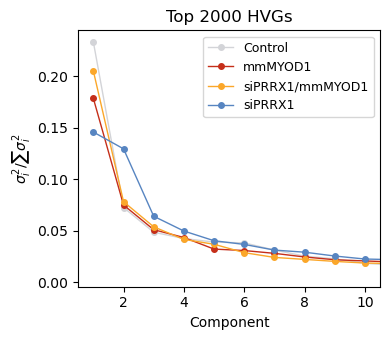

In [24]:
fig, ax = plt.subplots(figsize=(4, 3.5))

for cond in cond_order:
    n_pcs = results[cond]['n_pcs']
    ax.plot(range(1, n_pcs + 1), results[cond]['normalized_sv_squared'],
            marker='o', markersize=4, linewidth=1,
            color=colors[cond], label=cond)

ax.set_xlabel('Component')
ax.set_ylabel('$σ_i^2$/∑$σ_i^2$')
# ax.set_title(f'Normalized Singular Values\nFibroblast genes ({len(gene_list)} genes)')
# ax.set_title(f'Fibroblast genes ({len(gene_list)} genes)')
ax.set_title(f'Top {len(adata.var[adata.var['highly_variable'] == True])} HVGs')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0.5, 10.5])

plt.tight_layout()
plt.show()

# A matrices

Gene-gene correlation matrices for each condition

In [32]:
gene_list = fib_genes.copy()

gene_list = [g for g in gene_list if g in adata.var_names]


# subset adata for genes in gene set
# bdata = adata[:, gene_list].copy()
bdata = adata[adata.obs['pooled_condition'] == 'Control', gene_list].copy()

print(f"Data shape: {bdata.shape}")
bdata.X = bdata.layers['log_norm'].copy()

# get gene names
gene_names = bdata.var_names

# dense format
X = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=bdata.obs_names,
    columns=bdata.var_names,
)

print(X_df.shape)
display(X_df.head())

R = X_df.corr()
print(R.shape)
display(R.head())

Data shape: (6960, 220)
(6960, 220)


gene_name,RARRES2,CELA1,LUM,PRRX1,SCARA5,COL1A1,COL5A2,COL5A1,FNDC1,COL12A1,...,KLF2,KLF9,ERCC1,GREM1,KLF6,COL8A1,PTX3,CEBPB,PKD2,CTHRC1
AAACCAAAGGGTAGCA_control,1.085324,0.0,0.904340,1.371333,0.0,3.001411,1.238519,0.683198,0.0,0.683198,...,0.398843,0.000000,0.683198,1.371333,0.904340,0.398843,0.0,0.398843,0.000000,1.085324
AAACCAAAGTAAGGGT_control,0.000000,0.0,2.383565,1.088123,0.0,3.450458,0.000000,0.685291,0.0,0.685291,...,0.000000,0.000000,0.000000,1.932404,0.685291,0.000000,0.0,0.000000,0.000000,0.000000
AAACCATTCAGGTAGG_control,0.000000,0.0,1.097148,0.692049,0.0,3.723549,1.251194,1.097148,0.0,0.914973,...,0.404733,0.000000,0.000000,2.523707,0.692049,0.000000,0.0,0.000000,0.692049,0.914973
AAACCATTCCAGCCCT_control,0.000000,0.0,2.447522,0.000000,0.0,3.531860,0.919694,1.182581,0.0,0.919694,...,0.000000,0.919694,0.000000,0.562048,0.000000,0.000000,0.0,0.000000,0.562048,0.562048
AAACCATTCGTGACCG_control,1.496135,0.0,1.673446,1.673446,0.0,4.106947,1.496135,1.280462,0.0,2.070503,...,0.000000,0.623851,0.623851,2.698512,0.000000,0.623851,0.0,0.000000,0.000000,0.623851


(220, 220)


gene_name,RARRES2,CELA1,LUM,PRRX1,SCARA5,COL1A1,COL5A2,COL5A1,FNDC1,COL12A1,...,KLF2,KLF9,ERCC1,GREM1,KLF6,COL8A1,PTX3,CEBPB,PKD2,CTHRC1
gene_name,,,,,,,,,,,,,,,,,,,,,
RARRES2,1.000000,0.032409,0.190281,0.030547,-0.002442,0.011386,0.019714,-0.000109,-0.007460,0.059403,...,-0.034703,0.029307,0.003425,-0.073112,-0.053840,0.059819,-0.021570,0.007887,-0.033697,-0.029707
CELA1,0.032409,1.000000,-0.009545,-0.019532,-0.000285,-0.006669,-0.007013,0.000709,-0.001933,0.005224,...,-0.004834,-0.005628,0.005764,0.014183,-0.014549,-0.008208,-0.006108,-0.007856,-0.011310,-0.007907
LUM,0.190281,-0.009545,1.000000,0.107380,0.006848,0.210761,0.112408,0.121560,-0.007128,0.149927,...,-0.046460,0.110467,-0.006503,0.071547,-0.100480,0.086798,-0.043705,0.074601,-0.069889,0.020388
PRRX1,0.030547,-0.019532,0.107380,1.000000,0.008560,-0.038057,0.005695,-0.012092,-0.029626,0.082963,...,-0.058248,0.068346,-0.013607,-0.015645,0.005634,0.055676,-0.046778,0.069549,-0.036276,0.038812
SCARA5,-0.002442,-0.000285,0.006848,0.008560,1.000000,-0.006313,0.007974,-0.005553,-0.003832,-0.018146,...,-0.009586,0.008232,0.005342,0.016653,0.008088,-0.016276,0.001731,-0.006268,0.007020,-0.000504


In [37]:
mean = X.mean(axis=0)
std = X.std(axis=0, ddof=1)

valid_genes = std > 0

Z = np.zeros_like(X)
Z[:, valid_genes] = (X[:, valid_genes] - mean[valid_genes]) / std[valid_genes]

# std[std == 0] = 1

# Z = (X - mean) / std

print(Z.shape)

corr = (Z.T @ Z) / (Z.shape[0] - 1)

corr = pd.DataFrame(
    corr,
    index=X_df.columns,
    columns=X_df.columns,
)

print(corr.shape)
corr.head()

(6960, 220)
(220, 220)


gene_name,RARRES2,CELA1,LUM,PRRX1,SCARA5,COL1A1,COL5A2,COL5A1,FNDC1,COL12A1,...,KLF2,KLF9,ERCC1,GREM1,KLF6,COL8A1,PTX3,CEBPB,PKD2,CTHRC1
gene_name,,,,,,,,,,,,,,,,,,,,,
RARRES2,1.000028,0.032411,0.190284,0.030548,-0.002442,0.011386,0.019714,-0.000109,-0.007460,0.059403,...,-0.034703,0.029307,0.003425,-0.073113,-0.053841,0.059821,-0.021570,0.007887,-0.033697,-0.029707
CELA1,0.032411,1.000116,-0.009545,-0.019533,-0.000285,-0.006669,-0.007014,0.000709,-0.001933,0.005224,...,-0.004835,-0.005629,0.005764,0.014184,-0.014550,-0.008209,-0.006108,-0.007857,-0.011311,-0.007908
LUM,0.190284,-0.009545,1.000001,0.107380,0.006848,0.210762,0.112408,0.121560,-0.007128,0.149927,...,-0.046460,0.110466,-0.006503,0.071548,-0.100481,0.086801,-0.043704,0.074600,-0.069887,0.020388
PRRX1,0.030548,-0.019533,0.107380,1.000003,0.008560,-0.038057,0.005695,-0.012092,-0.029625,0.082962,...,-0.058247,0.068346,-0.013607,-0.015645,0.005634,0.055677,-0.046778,0.069548,-0.036275,0.038812
SCARA5,-0.002442,-0.000285,0.006848,0.008560,0.999956,-0.006313,0.007974,-0.005553,-0.003832,-0.018146,...,-0.009586,0.008232,0.005342,0.016653,0.008088,-0.016276,0.001731,-0.006268,0.007019,-0.000504


In [6]:
# 1. subset for genes of interest
gene_list = fib_genes.copy()
# gene_list = combined_markers.copy()
# gene_list = myo_genes.copy()
# gene_list = tf_list.copy()

gene_list = [g for g in gene_list if g in adata.var_names]

# subset adata for genes in gene set
bdata = adata[:, gene_list].copy()
print(f"Data shape: {bdata.shape}")
bdata.X = bdata.layers['log_norm'].copy()

# get gene names
gene_names = bdata.var_names

# dense format
X_all = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()


adjacency_matrices_unsigned = {}
adjacency_matrices_signed = {}

# get gene-gene correlation matrices for each condition separately
for cond, group in bdata.obs.groupby('pooled_condition', observed=True):
    # Filter X for this condition
    idx = bdata.obs['pooled_condition'] == cond
    X_sub = X_all[idx, :]
    
    # 1. Compute means and standard deviations for each gene with ddof=1 (Pandas default)
    means = np.mean(X_sub, axis=0)
    stds = np.std(X_sub, axis=0, ddof=1)
    # print(means.shape) # (N genes,)
    # print(stds.shape) # (N genes,)
    
    # 2. Identify genes with zero variance (no expression)
    valid_genes = stds > 0
    
    # 3. Z-score only the valid genes; non-valid genes remain as 0
    Z = np.zeros_like(X_sub)
    Z[:, valid_genes] = (X_sub[:, valid_genes] - means[valid_genes]) / stds[valid_genes]
    
    # 4. Compute correlation (N-1)
    # Results for zero-variance genes will be 0
    A_np = (Z.T @ Z) / (X_sub.shape[0] - 1)
    print(f"A shape: {A_np.shape}\n")
    
    # 5. Clean up diagonal and wrap in DF
    np.fill_diagonal(A_np, 0)
    A_df = pd.DataFrame(A_np, index=gene_names, columns=gene_names)

    # Apply a threshold to sparsify the matrix (and retain more meaningful edges)
    threshold = 0.3
    A_thresh = A_df.abs()
    A_thresh[A_thresh < threshold] = 0.0
    
    # # store unsigned A (correlation strength only)
    # adjacency_matrices_unsigned[cond] = A_df.abs()
    adjacency_matrices_unsigned[cond] = A_thresh
    
    # store signed A: shift [-1, 1] to [0, 1] to ensure non-negative weights
    A_signed = (A_df + 1) / 2
    np.fill_diagonal(A_signed.values, 0)
    # adjacency_matrices_signed[cond] = A_signed
    
    A_signed[A_df.abs() < threshold] = 0.0
    adjacency_matrices_signed[cond] = A_signed
    
    n_nonzero = (A_thresh.values[np.triu_indices_from(A_thresh.values, k=1)] > 0).sum()
    print(f"N non-zero edges after threshold for {cond}: {n_nonzero}")
    # break

print("Done!")

Data shape: (15950, 220)
A shape: (220, 220)

N non-zero edges after threshold for Control: 53
A shape: (220, 220)

N non-zero edges after threshold for mmMYOD1: 241
A shape: (220, 220)

N non-zero edges after threshold for siPRRX1: 82
A shape: (220, 220)

N non-zero edges after threshold for siPRRX1/mmMYOD1: 258
Done!


In [39]:
### using .corr
gene_list = fib_genes.copy()
# gene_list = combined_markers.copy()
# gene_list = myo_genes.copy()
# gene_list = tf_list.copy()

gene_list = [g for g in gene_list if g in adata.var_names]

# Subset adata for genes in gene set
bdata = adata[:, gene_list].copy()
print(f"Data shape: {bdata.shape}")

# Use log-normalized layer
bdata.X = bdata.layers['log_norm'].copy()

gene_names = bdata.var_names

# Ensure dense format
X_all = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()

adjacency_matrices_unsigned = {}
adjacency_matrices_signed = {}

# Compute gene–gene correlation matrices for each condition
for cond, group in bdata.obs.groupby('pooled_condition', observed=True):

    idx = bdata.obs['pooled_condition'] == cond
    X_sub = X_all[idx, :]

    # Convert to DataFrame (cells × genes)
    X_df = pd.DataFrame(
        X_sub,
        columns=gene_names
    )

    # Compute Pearson correlation (gene × gene)
    A_df = X_df.corr(method='pearson')

    print(f"A shape: {A_df.shape}\n")

    # Replace NaNs (from zero-variance genes) with 0
    A_df = A_df.fillna(0)

    # Remove self-loops
    np.fill_diagonal(A_df.values, 0)

    # Apply threshold to sparsify
    threshold = 0.3
    A_thresh = A_df.abs()
    A_thresh[A_thresh < threshold] = 0.0

    adjacency_matrices_unsigned[cond] = A_thresh

    # Signed version: shift [-1,1] → [0,1]
    A_signed = (A_df + 1) / 2
    np.fill_diagonal(A_signed.values, 0)

    A_signed[A_df.abs() < threshold] = 0.0
    adjacency_matrices_signed[cond] = A_signed

    # Count nonzero edges (upper triangle only)
    n_nonzero = (
        A_thresh.values[np.triu_indices_from(A_thresh.values, k=1)] > 0
    ).sum()

    print(f"N non-zero edges after threshold for {cond}: {n_nonzero}")

print("Done!")

Data shape: (15950, 220)
A shape: (220, 220)

N non-zero edges after threshold for Control: 53
A shape: (220, 220)

N non-zero edges after threshold for mmMYOD1: 241
A shape: (220, 220)

N non-zero edges after threshold for siPRRX1: 82
A shape: (220, 220)

N non-zero edges after threshold for siPRRX1/mmMYOD1: 258
Done!


# Shannon entropy and VGNE

Shannon entropy is computed over the union of non-zero edges across conditions (e.g., non-zero in any condition), so the number of edges is identical and makes entropy directly comparable across conditions.

In [40]:
# Use unsigned for the following calculations
adjacency_matrices = adjacency_matrices_unsigned.copy()


#### create shared edge mask
sample_A = next(iter(adjacency_matrices.values()))
upper_tri = np.triu_indices_from(sample_A.values, k=1)

# Get boolean masks for nonzero edges per condition
edge_masks = {}
for cond, A in adjacency_matrices.items():
    vals = A.values[upper_tri]
    edge_masks[cond] = vals > 0

# Union mask: edge is active in AT LEAST one condition
union_mask = np.zeros(len(edge_masks[list(edge_masks.keys())[0]]), dtype=bool)
for mask in edge_masks.values():
    union_mask |= mask

# Intersection mask: edge is active in ALL conditions
intersection_mask = np.ones(len(edge_masks[list(edge_masks.keys())[0]]), dtype=bool)
for mask in edge_masks.values():
    intersection_mask &= mask

print(f"Total upper triangle edges: {len(union_mask)}")
print(f"Union mask (active in any condition): {union_mask.sum()}")
print(f"Intersection mask (active in all conditions): {intersection_mask.sum()}\n")

# Choose which mask to use
shared_mask = union_mask  # or intersection_mask



# 3. Initialize result containers
entropies = {}
vn_entropies = {}
KL_divergences = {}

max_entropies = {}
max_vn_entropies = {}

top_edges_per_condition = {}
top_genes_per_condition = {}

# 4. Compute Shannon Entropy and von Neumann Graph Entropy (VNGE)
for cond, A in adjacency_matrices.items():
    # --- Standard Shannon Entropy (Edge Weights) ---
    upper_tri = np.triu_indices_from(A, k=1)
    # values = A.values[upper_tri]
    # values = values[~np.isnan(values)]
    # # values = values[values > 0] # remove zero-weight edges
    values = A.values[upper_tri][shared_mask]
    values = np.nan_to_num(values, nan=0.0)  # treat NaNs as 0 within shared edge set
    
    # compute entropy
    p = values / np.sum(values)
    entropies[cond] = -np.sum(p * np.log2(p + 1e-12))
    
    # determine max entropy
    N_edges = len(values)
    print(f"N edges for {cond}: {N_edges}") 
    max_entropies[cond] = np.log2(N_edges) if N_edges > 0 else 0.0
    
    
    # --- von Neumann Graph Entropy (Topology) ---
    W = A.values
    W = np.nan_to_num(W, nan=0.0, posinf=0.0, neginf=0.0) # ensure no NaNs exist in the weight matrix
    
    print(f"W nonzero entries (upper tri): {(W[np.triu_indices_from(W, k=1)] > 0).sum()}")
    
    d = np.sum(W, axis=1)
    
    # Compute Normalized Laplacian: L = I - D^(-1/2) W D^(-1/2)
    # Handle zero-degree nodes safely to avoid division by 0
    # we only take the reciprocal where d > 0; otherwise, it stays 0
    d_inv_sqrt = np.zeros_like(d)
    nonzero_mask = d > 0
    d_inv_sqrt[nonzero_mask] = 1.0 / np.sqrt(d[nonzero_mask])
    
    D_inv_sqrt = np.diag(d_inv_sqrt)
    
    L_norm = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt
    
    # Zero out rows/cols of isolated nodes so they contribute eigenvalue 0 (otherwise they contribute eig of 1 and inflate non-zero count)
    isolated = d == 0
    L_norm[isolated, :] = 0.0
    L_norm[:, isolated] = 0.0
    
    
    print(f"Degree zero nodes: {(d == 0).sum()}")
    print(f"L_norm diagonal unique values (first 10): {np.unique(np.diag(L_norm))[:10]}")
    print(f"L_norm nonzero off-diagonal (upper tri): {(L_norm[np.triu_indices_from(L_norm, k=1)] != 0).sum()}")
    

    if not np.isfinite(L_norm).all():
        print(f"⚠️ Warning: L_norm for {cond} still contains non-finite values. Skipping VNGE.")
        vn_entropies[cond] = np.nan
        max_vn_entropies[cond] = np.nan
        continue
    
    # Eigenvalues of the Laplacian
    eigenvalues = eigvalsh(L_norm)
    # print("Raw smallest eigenvalues:", np.sort(eigenvalues)[:10])
    eigenvalues = np.maximum(eigenvalues, 0) # Precision cleanup; makes any negative values = 0
    
    # print(f"Eigenvalues near zero: {np.sort(eigenvalues)[:200]}") # checked to see where to threshold non-zero eigenvalues; 1e-6 is good
    
    # Normalize eigenvalues to sum to 1 (Density Matrix rho)
    eig_thresh = 1e-6 
    
    # Count near-zero eigenvalues
    n_zero_eigs = np.sum(eigenvalues <= eig_thresh)
    print(f"N eigs <= {eig_thresh} for {cond}: {n_zero_eigs}")
    
    # Fiedler value (2nd smallest eigenvalue)
    eigs_sorted = np.sort(eigenvalues)
    
    if len(eigs_sorted) > 1:
        # fiedler_value = eigs_sorted[eigs_sorted > eig_thresh][0] #eigs_sorted[1]
        fiedler_value = eigs_sorted[1]
    else:
        fiedler_value = np.nan
        
    print(f"Fiedler value for {cond}: {fiedler_value}")
    
    # N_nonzero_eigs1 = np.sum(eigenvalues > eig_thresh)
    # print(f"N non-zero eigs for {cond}: {N_nonzero_eigs1}\n")
    
    # VNGE normalization
    rho = eigenvalues / np.sum(eigenvalues)
    # print(rho.max(), rho.min())
    
    N_nonzero_eigs = np.sum(rho > eig_thresh)
    print(f"N non-zero eigs for {cond}: {N_nonzero_eigs}\n")
    
    rho = rho[rho > eig_thresh] # Filter out near-zero values
    
    # print("rho > eig_thresh:", np.sort(rho)[:10])
    
    vn_entropies[cond] = -np.sum(rho * np.log2(rho))
    
    # compute max VGNE
    max_vn_entropies[cond] = np.log2(N_nonzero_eigs) if N_nonzero_eigs > 0 else 0.0
    

    # break
    
# entropy dfs
entropy_df = pd.DataFrame(list(entropies.items()), columns=['condition', 'entropy']).sort_values('entropy', ascending=False)
vn_entropy_df = pd.DataFrame(list(vn_entropies.items()), columns=['condition', 'vn_entropy']).sort_values('vn_entropy', ascending=False)

# display(entropy_df)
# display(vn_entropy_df)

# build comparison dfs
max_entropy_df = pd.DataFrame(list(max_entropies.items()), columns=['condition', 'max_entropy']).sort_values('max_entropy', ascending=False)
max_vn_entropy_df = pd.DataFrame(list(max_vn_entropies.items()), columns=['condition', 'max_vn_entropy']).sort_values('max_vn_entropy', ascending=False)

# merge observed vs max for direct comparison
shannon = entropy_df.merge(max_entropy_df, on='condition')
shannon['pct_of_max'] = (shannon['entropy'] / shannon['max_entropy'])#.round(3)

vnge = vn_entropy_df.merge(max_vn_entropy_df, on='condition')
vnge['pct_of_max'] = (vnge['vn_entropy'] / vnge['max_vn_entropy'])#.round(3)


print("=== Shannon Entropy: Observed vs Maximum ===")
display(shannon)

print("\n=== VNGE: Observed vs Maximum ===")
display(vnge)

Total upper triangle edges: 24090
Union mask (active in any condition): 387
Intersection mask (active in all conditions): 19

N edges for Control: 387
W nonzero entries (upper tri): 53
Degree zero nodes: 184
L_norm diagonal unique values (first 10): [0. 1.]
L_norm nonzero off-diagonal (upper tri): 53
N eigs <= 1e-06 for Control: 187
Fiedler value for Control: 0.0
N non-zero eigs for Control: 33

N edges for mmMYOD1: 387
W nonzero entries (upper tri): 241
Degree zero nodes: 167
L_norm diagonal unique values (first 10): [0. 1.]
L_norm nonzero off-diagonal (upper tri): 241
N eigs <= 1e-06 for mmMYOD1: 169
Fiedler value for mmMYOD1: 0.0
N non-zero eigs for mmMYOD1: 51

N edges for siPRRX1: 387
W nonzero entries (upper tri): 82
Degree zero nodes: 184
L_norm diagonal unique values (first 10): [0. 1.]
L_norm nonzero off-diagonal (upper tri): 82
N eigs <= 1e-06 for siPRRX1: 186
Fiedler value for siPRRX1: 0.0
N non-zero eigs for siPRRX1: 34

N edges for siPRRX1/mmMYOD1: 387
W nonzero entries (u

,condition,entropy,max_entropy,pct_of_max
0,siPRRX1/mmMYOD1,7.987034,8.59619,0.929137
1,mmMYOD1,7.894239,8.59619,0.918342
2,siPRRX1,6.327066,8.59619,0.736031
3,Control,5.685126,8.59619,0.661354



=== VNGE: Observed vs Maximum ===


,condition,vn_entropy,max_vn_entropy,pct_of_max
0,siPRRX1/mmMYOD1,5.649871,5.700440,0.991129
1,mmMYOD1,5.599951,5.672425,0.987223
2,siPRRX1,5.008023,5.087463,0.984385
3,Control,4.903238,5.044394,0.972017


In [41]:
for cond, A in adjacency_matrices.items():
    G = nx.from_pandas_adjacency(A)
    is_conn = nx.is_connected(G)
    n_components = nx.number_connected_components(G)
    largest = max(nx.connected_components(G), key=len)
    print(f"{cond}: Connected? {is_conn}, {n_components} components, largest has {len(largest)} nodes")

Control: Connected? False, 187 components, largest has 29 nodes
mmMYOD1: Connected? False, 169 components, largest has 50 nodes
siPRRX1: Connected? False, 186 components, largest has 32 nodes
siPRRX1/mmMYOD1: Connected? False, 168 components, largest has 53 nodes


In [42]:
# check threshold is actually applied
A = adjacency_matrices['Control']
upper_vals = A.values[np.triu_indices_from(A.values, k=1)]
print(f"Total entries: {len(upper_vals)}")
print(f"Exactly zero: {(upper_vals == 0.0).sum()}")
print(f"Between 0 and 0.3: {((upper_vals > 0) & (upper_vals < 0.3)).sum()}")
print(f"Above 0.3: {(upper_vals >= 0.3).sum()}")

Total entries: 24090
Exactly zero: 24037
Between 0 and 0.3: 0
Above 0.3: 53


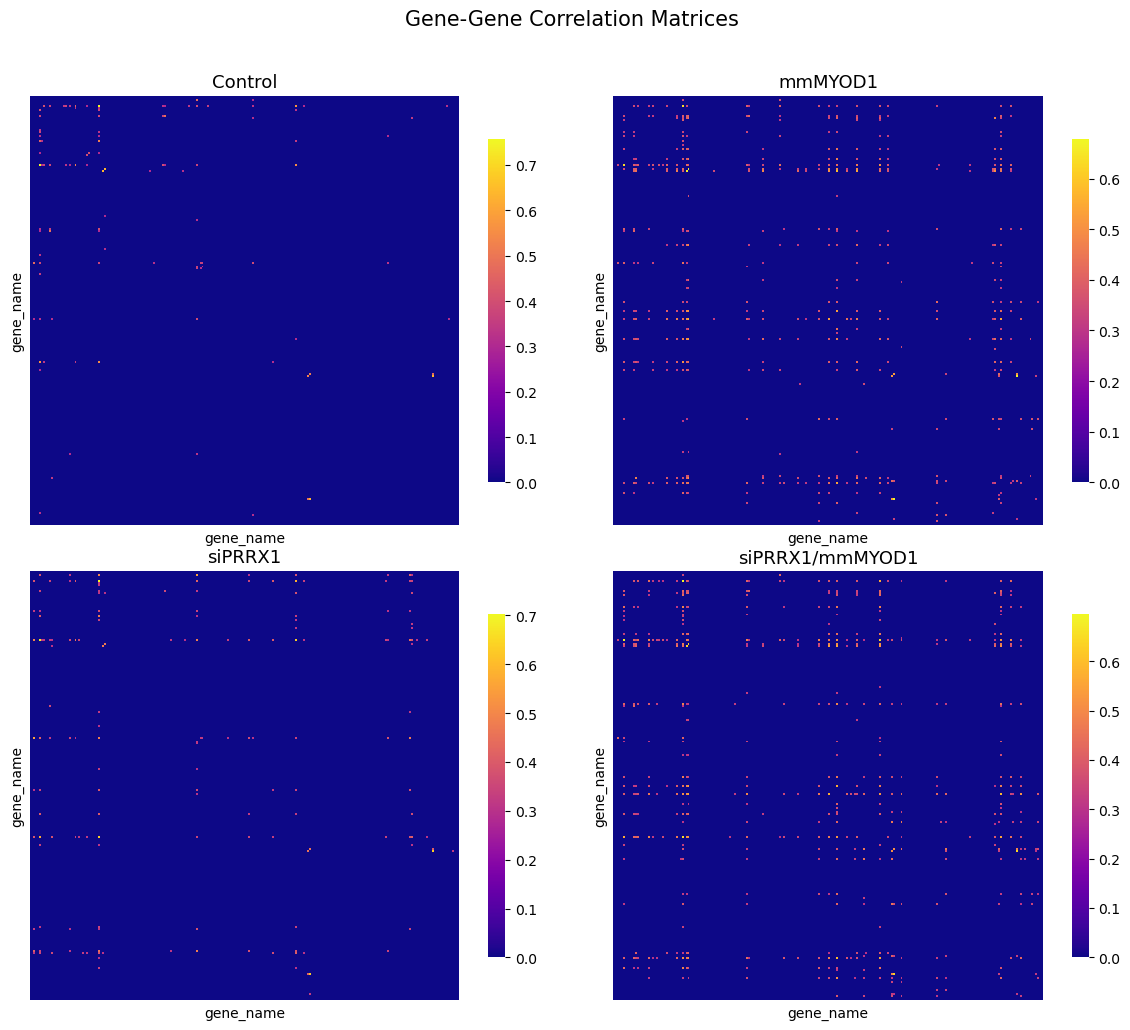

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (condition, matrix) in zip(axes, adjacency_matrices.items()):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap='plasma',  # or 'viridis', 'RdBu_r', etc.
        # center=0,         # useful for correlation matrices (-1 to 1)
        # vmin=-1, vmax=1,
        xticklabels=False,
        yticklabels=False,
        square=True,      # keeps cells square
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(condition, fontsize=13)

plt.suptitle('Gene-Gene Correlation Matrices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# KL divergence

Symmetrized KL divergence relative to control

In [43]:
# 5. Compute KL Divergence (Relative to Control)
control_A = adjacency_matrices['Control']
upper_tri = np.triu_indices_from(control_A, k=1)
print(f"Total edges in upper triangle: {len(control_A.values[upper_tri])}")

# # Create consistent mask for edges present in ALL conditions
# mask_upper = np.ones_like(control_A.values[upper_tri], dtype=bool)
# for A in adjacency_matrices.values():
#     mask_upper &= ~np.isnan(A.values[upper_tri])

# Use shared union mask from entropy calculations
mask_upper = shared_mask
print(f"Active edges (union mask): {mask_upper.sum()}")


control_values = np.abs(control_A.values[upper_tri][mask_upper])
p_control = control_values / (np.sum(control_values) + 1e-12)
genes = control_A.columns

n_top = 50

for condition, A in adjacency_matrices.items():
    if condition == 'Control':
        KL_divergences[condition] = 0.0
        continue

    values = np.abs(A.values[upper_tri][mask_upper])
    if np.sum(values) == 0:
        KL_divergences[condition] = np.nan
        continue

    p_cond = values / np.sum(values)
    eps = 1e-12
    p_cond_adj = p_cond + eps
    p_control_adj = p_control + eps

    # # Non symmetrized version
    # KL_divergences[condition] = np.sum(p_cond_adj * np.log2(p_cond_adj / p_control_adj))
    
    # Symmetrized KL
    kl_cond_ctrl = p_cond_adj * np.log2(p_cond_adj / p_control_adj)
    kl_ctrl_cond = p_control_adj * np.log2(p_control_adj / p_cond_adj)
    
    delta = 0.5 * (kl_cond_ctrl + kl_ctrl_cond)
    KL_divergences[condition] = np.sum(delta)
    
    # Edge/Gene importance (decomposition of KL)
    # delta = p_cond_adj * np.log2(p_cond_adj / p_control_adj)
    edges = np.array([(genes[i], genes[j]) for i, j in zip(*upper_tri)])[mask_upper]
    
    df_edges = pd.DataFrame({"gene_i": edges[:, 0], "gene_j": edges[:, 1], "delta_KL": delta}).sort_values(by="delta_KL", ascending=False)
    top_edges_per_condition[condition] = df_edges.head(n_top)   
    
    gene_importance = pd.concat([df_edges.groupby("gene_i")["delta_KL"].sum(), 
                                 df_edges.groupby("gene_j")["delta_KL"].sum()], axis=1).sum(axis=1).sort_values(ascending=False)
    top_genes_per_condition[condition] = gene_importance.head(n_top)

kl_df = pd.DataFrame(list(KL_divergences.items()), columns=['condition', 'KL_divergence']).sort_values('KL_divergence', ascending=False)


display(kl_df)

Total edges in upper triangle: 24090
Active edges (union mask): 387


,condition,KL_divergence
1,mmMYOD1,21.190865
3,siPRRX1/mmMYOD1,21.150413
2,siPRRX1,17.395877
0,Control,0.000000


# Plotting

In [44]:
for df in [shannon, vnge, kl_df]:
    df['condition'] = df['condition'].replace({
        'siPRRX1/mmMYOD1': 'HYB'
    })
    
shannon

,condition,entropy,max_entropy,pct_of_max
0,HYB,7.987034,8.59619,0.929137
1,mmMYOD1,7.894239,8.59619,0.918342
2,siPRRX1,6.327066,8.59619,0.736031
3,Control,5.685126,8.59619,0.661354


Plotting Network Metrics...


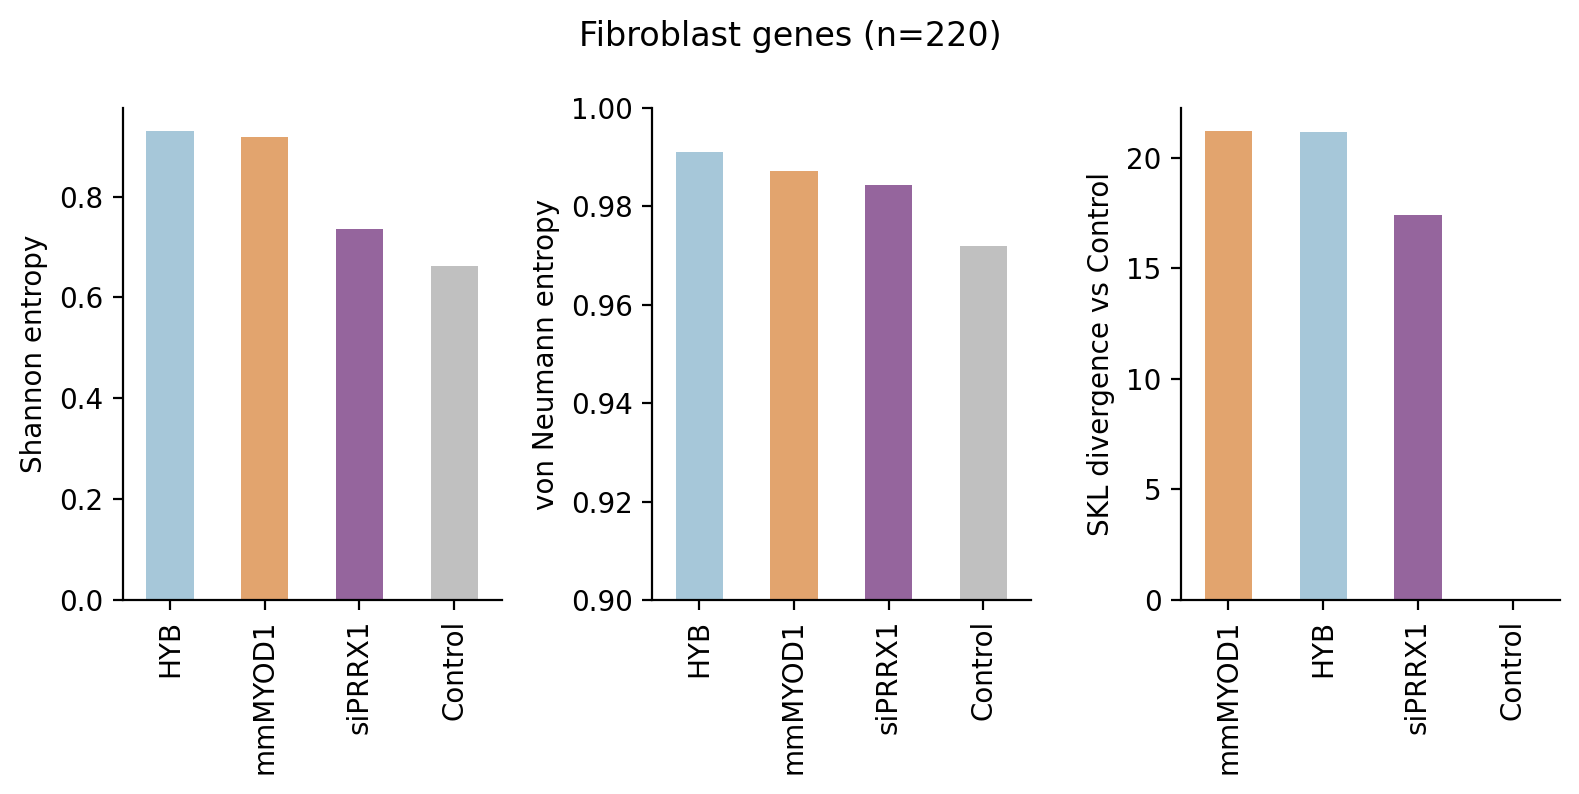

In [45]:
print("Plotting Network Metrics...")
fig, axes = plt.subplots(1, 3, figsize=(8, 4), dpi=200)

palette = {
    'Control': 'silver',
    'siPRRX1': '#9B5CA6',
    'mmMYOD1': '#F5A35B',
    'HYB': '#9ECAE1',
}

bar_width = 0.5

# Shannon Entropy
sns.barplot(data=shannon, x='condition', y='pct_of_max', hue='condition', legend=False, ax=axes[0], palette=palette, width=bar_width)
# axes[0].set_title("Edge Weight Entropy")
# axes[0].set_yscale('log')
axes[0].set_ylabel('Shannon entropy')

# von Neumann Entropy
sns.barplot(data=vnge, x='condition', y='pct_of_max', hue='condition', legend=False, ax=axes[1], palette=palette, width=bar_width)
# axes[1].set_title("Structural Complexity (VNGE)")
# axes[1].set_yscale('log')
axes[1].set_ylim([0.9, 1])
axes[1].set_ylabel('von Neumann entropy')

# KL Divergence
sns.barplot(data=kl_df, x='condition', y='KL_divergence', hue='condition', legend=False, ax=axes[2], palette=palette, width=bar_width)
# axes[2].set_title("SKL Divergence vs Control")
axes[2].set_ylabel('SKL divergence vs Control')

for ax in axes:
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xlabel("")

    
plt.suptitle('Fibroblast genes (n=220)')
# plt.suptitle('Fibroblast and muscle genes (n=386)')
# plt.suptitle('Muscle genes (n=210)')
# plt.suptitle('Transcription factors (n=1,357)')

sns.despine()
plt.tight_layout()
plt.show()

# Bootstrapping

In [12]:
n_iterations = 1000
subsample_frac = 0.8
threshold = 0.3
eig_thresh = 1e-6
condition_order = ['Control', 'siPRRX1', 'mmMYOD1', 'siPRRX1/mmMYOD1']


# 1. subset for genes of interest
gene_list = fib_genes.copy()
# gene_list = tf_list.copy()

gene_list = [g for g in gene_list if g in adata.var_names]

# subset adata for genes in gene set
bdata = adata[:, gene_list].copy()
print(f"Data shape: {bdata.shape}")
bdata.X = bdata.layers['log_norm'].copy()

# get gene names
gene_names = bdata.var_names

# dense format
X_all = bdata.X if isinstance(bdata.X, np.ndarray) else bdata.X.toarray()


# Get cell indices per condition
condition_indices = {
    cond: np.where(bdata.obs['pooled_condition'] == cond)[0]
    for cond in condition_order
}
# Use smallest condition size to determine subsample size
min_cells = min(len(idx) for idx in condition_indices.values())
n_subsample = int(min_cells * subsample_frac)
print(f"Cells per condition: { {c: len(v) for c, v in condition_indices.items()} }")
print(f"Subsampling {n_subsample} cells per condition per iteration")

Data shape: (15950, 220)
Cells per condition: {'Control': 6960, 'siPRRX1': 3430, 'mmMYOD1': 2109, 'siPRRX1/mmMYOD1': 3451}
Subsampling 1687 cells per condition per iteration


In [ ]:
# use constant shared edge mask -- from full population

In [13]:
# --- Result containers ---
bootstrap_shannon = {cond: [] for cond in condition_order}
bootstrap_vnge    = {cond: [] for cond in condition_order}
bootstrap_kl      = {cond: [] for cond in condition_order}

for it in range(n_iterations):
    if (it + 1) % 50 == 0:
        print(f"Iteration {it + 1}/{n_iterations}")

    # --- 1. Build adjacency matrices from subsampled cells ---
    adj_matrices = {}
    for cond, idx in condition_indices.items():
        sub_idx = np.random.choice(idx, size=n_subsample, replace=False)
        X_sub = X_all[sub_idx, :]

        means = np.mean(X_sub, axis=0)
        stds  = np.std(X_sub, axis=0, ddof=1)

        valid_genes = stds > 0
        Z = np.zeros_like(X_sub)
        Z[:, valid_genes] = (X_sub[:, valid_genes] - means[valid_genes]) / stds[valid_genes]

        A_np = (Z.T @ Z) / (X_sub.shape[0] - 1)
        np.fill_diagonal(A_np, 0)
        A_df = pd.DataFrame(A_np, index=gene_names, columns=gene_names)

        A_thresh = A_df.abs()
        A_thresh[A_thresh < threshold] = 0.0
        adj_matrices[cond] = A_thresh

#     # --- 2. Build shared union mask for this iteration --- ### using union mask from full population computed above
#     sample_A  = next(iter(adj_matrices.values()))
#     upper_tri = np.triu_indices_from(sample_A.values, k=1)

#     union_mask = np.zeros(len(sample_A.values[upper_tri]), dtype=bool)
#     for A in adj_matrices.values():
#         union_mask |= (A.values[upper_tri] > 0)

    # --- 3. Shannon Entropy ---
    for cond, A in adj_matrices.items():
        values = A.values[upper_tri][union_mask]
        values = np.nan_to_num(values, nan=0.0)
        total  = np.sum(values)
        if total == 0:
            bootstrap_shannon[cond].append(np.nan)
            continue
        p = values / total
        N_edges = len(values)
        raw_entropy = -np.sum(p * np.log2(p + 1e-12))
        max_entropy = np.log2(N_edges) if N_edges > 0 else 1.0
        bootstrap_shannon[cond].append(raw_entropy / max_entropy)

    # --- 4. VNGE ---
    for cond, A in adj_matrices.items():
        W = np.nan_to_num(A.values, nan=0.0, posinf=0.0, neginf=0.0)
        d = np.sum(W, axis=1)

        d_inv_sqrt = np.zeros_like(d)
        nz = d > 0
        d_inv_sqrt[nz] = 1.0 / np.sqrt(d[nz])
        D_inv_sqrt = np.diag(d_inv_sqrt)

        L_norm = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt
        isolated = d == 0
        L_norm[isolated, :] = 0.0
        L_norm[:, isolated] = 0.0

        if not np.isfinite(L_norm).all():
            bootstrap_vnge[cond].append(np.nan)
            continue

        eigenvalues = np.maximum(eigvalsh(L_norm), 0)
        rho = eigenvalues / np.sum(eigenvalues)
        N_nonzero = np.sum(rho > eig_thresh)
        rho = rho[rho > eig_thresh]

        raw_vnge = -np.sum(rho * np.log2(rho))
        max_vnge = np.log2(N_nonzero) if N_nonzero > 0 else 1.0
        bootstrap_vnge[cond].append(raw_vnge / max_vnge)

    # --- 5. Symmetrized KL Divergence (vs Control) ---
    control_vals = np.abs(adj_matrices['Control'].values[upper_tri][union_mask])
    p_control    = control_vals / (np.sum(control_vals) + 1e-12)

    for cond in condition_order:
        if cond == 'Control':
            bootstrap_kl[cond].append(0.0)
            continue
        values = np.abs(adj_matrices[cond].values[upper_tri][union_mask])
        if np.sum(values) == 0:
            bootstrap_kl[cond].append(np.nan)
            continue
        p_cond        = values / np.sum(values)
        eps           = 1e-12
        p_cond_adj    = p_cond    + eps
        p_control_adj = p_control + eps
        kl_cond_ctrl  = p_cond_adj    * np.log2(p_cond_adj    / p_control_adj)
        kl_ctrl_cond  = p_control_adj * np.log2(p_control_adj / p_cond_adj)
        bootstrap_kl[cond].append(0.5 * np.sum(kl_cond_ctrl + kl_ctrl_cond))

print("Bootstrap complete!")

Iteration 50/1000
Iteration 100/1000
Iteration 150/1000
Iteration 200/1000
Iteration 250/1000
Iteration 300/1000
Iteration 350/1000
Iteration 400/1000
Iteration 450/1000
Iteration 500/1000
Iteration 550/1000
Iteration 600/1000
Iteration 650/1000
Iteration 700/1000
Iteration 750/1000
Iteration 800/1000
Iteration 850/1000
Iteration 900/1000
Iteration 950/1000
Iteration 1000/1000
Bootstrap complete!


## Shannon Entropy

In [118]:
# shannon
sdf = pd.DataFrame(bootstrap_shannon)
# sdf = pd.DataFrame(bootstrap_vnge)

print(sdf.shape)
display(sdf.head())

display(sdf.describe())

print("\nBootstrap CIs:")
ci = sdf.quantile([0.025, 0.975])
ci

(1000, 4)


,Control,siPRRX1,mmMYOD1,siPRRX1/mmMYOD1
0,0.969439,0.984825,0.987579,0.992088
1,0.967245,0.982958,0.982030,0.989792
2,0.960819,0.980714,0.984896,0.990858
3,0.969022,0.985775,0.987757,0.991738
4,0.968040,0.985753,0.986850,0.988112


,Control,siPRRX1,mmMYOD1,siPRRX1/mmMYOD1
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.969894,0.984259,0.985749,0.989860
std,0.003530,0.002042,0.001438,0.001345
min,0.960291,0.976171,0.980108,0.985329
25%,0.967385,0.982899,0.984735,0.988979
50%,0.969927,0.984623,0.985966,0.989938
75%,0.972356,0.985694,0.986910,0.990827
max,0.979813,0.988809,0.988554,0.992987



Bootstrap CIs:


,Control,siPRRX1,mmMYOD1,siPRRX1/mmMYOD1
0.025,0.963210,0.979879,0.982786,0.987090
0.975,0.976831,0.987574,0.987925,0.992216


In [119]:
# bias of each estimate (difference between the mean of the bootstrap distribution and observed value)
# observed entropy is the observed value from the full population (computed above)

observed_entropy = pd.Series(shannon.set_index('condition')['pct_of_max'].to_dict())

# observed_entropy = pd.Series(vnge.set_index('condition')['pct_of_max'].to_dict())


# small bias (relative to CI width) validates that the estimator is well-behaved)
bias = sdf.mean() - observed_entropy
bias

Control           -0.002123
mmMYOD1           -0.001474
siPRRX1           -0.000126
siPRRX1/mmMYOD1   -0.001269
dtype: float64

In [120]:
conditions = sdf.columns.tolist()
results = []

for c1, c2 in combinations(conditions, 2):
    diff = sdf[c1] - sdf[c2]
    # Bootstrap p-value: proportion of bootstrap differences that are on the opposite side of zero from the observed mean difference
    observed_diff = observed_entropy[c1] - observed_entropy[c2]
    # Two-tailed: shift distribution to be centered on null (zero)
    shifted = diff - diff.mean()  # center on zero under null
    p_val = np.mean(np.abs(shifted) >= np.abs(observed_diff))
    results.append({
        'condition_1': c1,
        'condition_2': c2,
        'mean_diff': diff.mean(),
        'ci_low': diff.quantile(0.025),
        'ci_high': diff.quantile(0.975),
        'p_value': p_val
    })

results_df = pd.DataFrame(results)
results_df['p_adj'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

results_df

,condition_1,condition_2,mean_diff,ci_low,ci_high,p_value,p_adj
0,Control,siPRRX1,-0.014365,-0.021900,-0.006027,0.004,0.0080
1,Control,mmMYOD1,-0.015855,-0.023434,-0.008621,0.000,0.0000
2,Control,siPRRX1/mmMYOD1,-0.019966,-0.026932,-0.012949,0.000,0.0000
3,siPRRX1,mmMYOD1,-0.001490,-0.006690,0.003232,0.245,0.2450
4,siPRRX1,siPRRX1/mmMYOD1,-0.005601,-0.010861,-0.001366,0.008,0.0120
5,mmMYOD1,siPRRX1/mmMYOD1,-0.004111,-0.007809,-0.000429,0.041,0.0492


In [128]:
print(results_df)

  condition_1      condition_2  mean_diff    ci_low   ci_high  p_value   p_adj
0     Control          siPRRX1  -0.014365 -0.021900 -0.006027    0.004  0.0080
1     Control          mmMYOD1  -0.015855 -0.023434 -0.008621    0.000  0.0000
2     Control  siPRRX1/mmMYOD1  -0.019966 -0.026932 -0.012949    0.000  0.0000
3     siPRRX1          mmMYOD1  -0.001490 -0.006690  0.003232    0.245  0.2450
4     siPRRX1  siPRRX1/mmMYOD1  -0.005601 -0.010861 -0.001366    0.008  0.0120
5     mmMYOD1  siPRRX1/mmMYOD1  -0.004111 -0.007809 -0.000429    0.041  0.0492


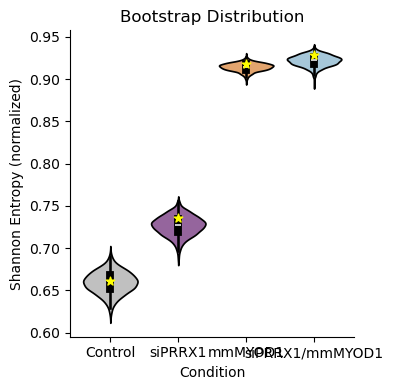

In [116]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.violinplot(
    data=sdf,
    ax=ax,
    inner='box',
    palette=palette,
    linecolor='k',
    # inner_kws={'linewidth': 0.5},
)

# overlay observed values
for i, col in enumerate(sdf.columns):
    ax.scatter(i, observed_entropy[col], color='yellow', zorder=5, s=40, marker='*')
ax.set_ylabel('Shannon Entropy (normalized)')
ax.set_xlabel('Condition')
ax.set_title('Bootstrap Distribution')
# ax.set_ylim([0.55, 1])

sns.despine()

plt.tight_layout()

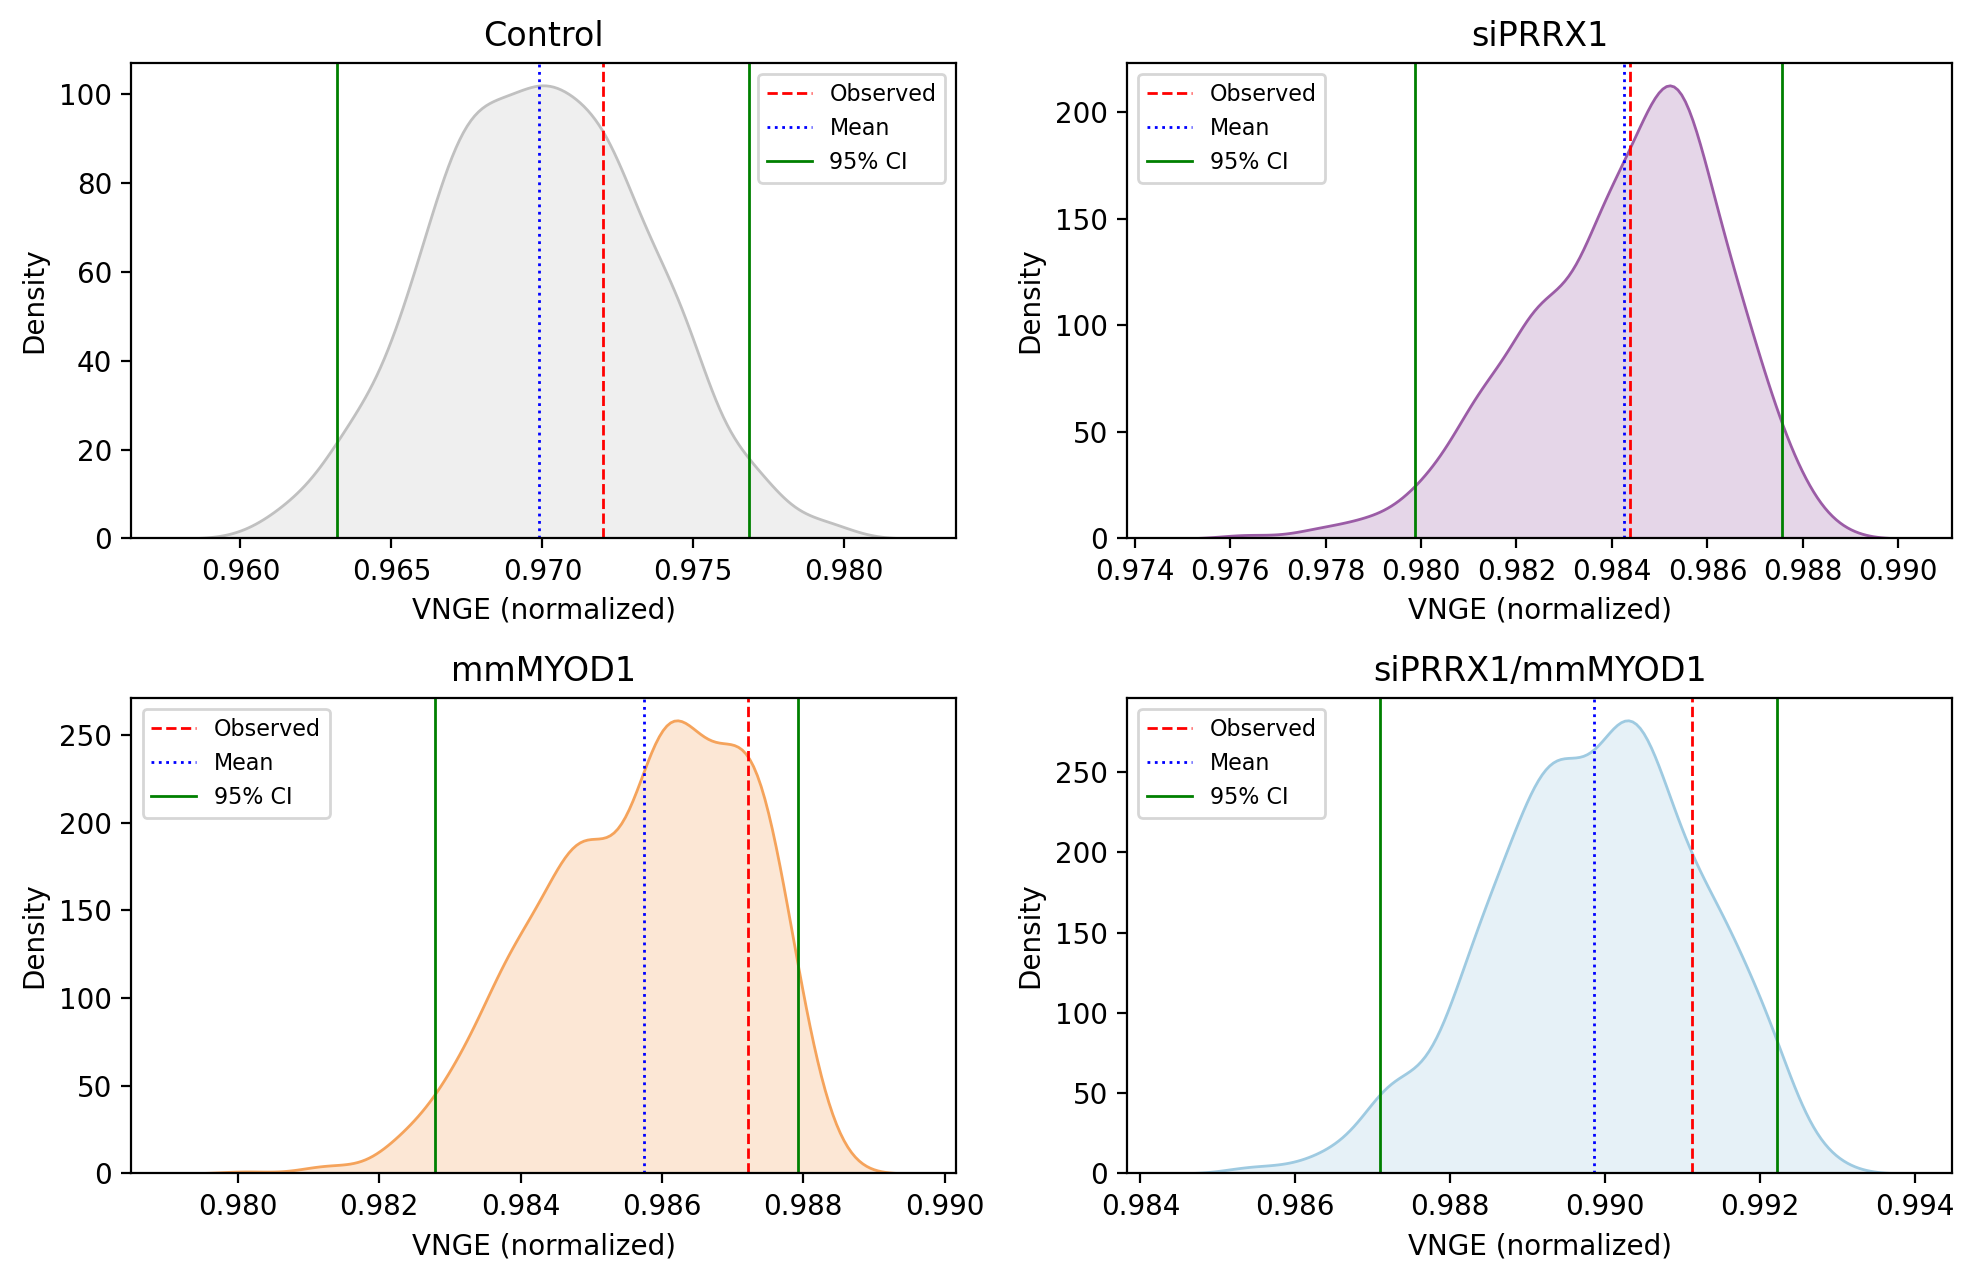

In [121]:
palette = {
    'Control': 'silver',
    'siPRRX1': '#9B5CA6',
    'mmMYOD1': '#F5A35B',
    'siPRRX1/mmMYOD1': '#9ECAE1',
}

fig, axs = plt.subplots(2, 2, figsize=(10, 6.5), dpi=200)
axs = axs.flatten()

for i, cond in enumerate(sdf.columns):
    ax = axs[i]
    
    ci_low, ci_high = np.percentile(sdf[cond], [2.5, 97.5])
    # sns.histplot(
    #     sdf[cond],
    #     ax=ax,
    #     kde=True,
    #     bins=25,
    # )
    
    sns.kdeplot(sdf[cond], ax=ax, fill=True, color=palette[cond])
    
    ax.axvline(observed_entropy[cond], ls='--', lw=1, c='r', label='Observed')
    
    ax.axvline(sdf[cond].mean(), ls=':', lw=1, c='b', label='Mean')
    
    ax.axvline(ci_low, c='g', ls='-', lw=1, label='95% CI')
    ax.axvline(ci_high, c='g', ls='-', lw=1)
    
    ax.set_title(cond)
    # ax.set_xlabel("Entropy (normalized)")
    ax.set_xlabel("VNGE (normalized)")
    ax.legend(fontsize=8)
    # ax.set_ylabel("Count")
    
    
plt.tight_layout()
plt.show()

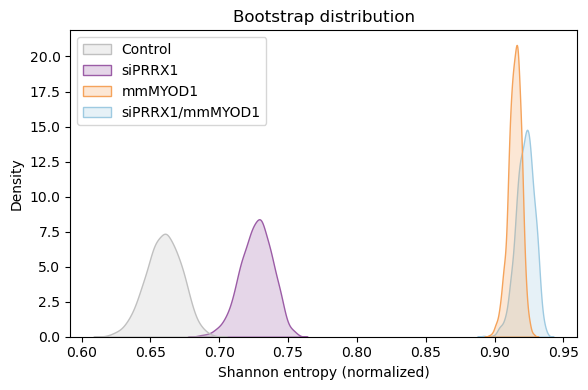

In [96]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.kdeplot(
    sdf,
    fill=True,
    palette=palette,
)

# plt.xlim([0.55, 1.25])

plt.title("Bootstrap distribution")
plt.xlabel("Shannon entropy (normalized)")

plt.tight_layout()
plt.show()

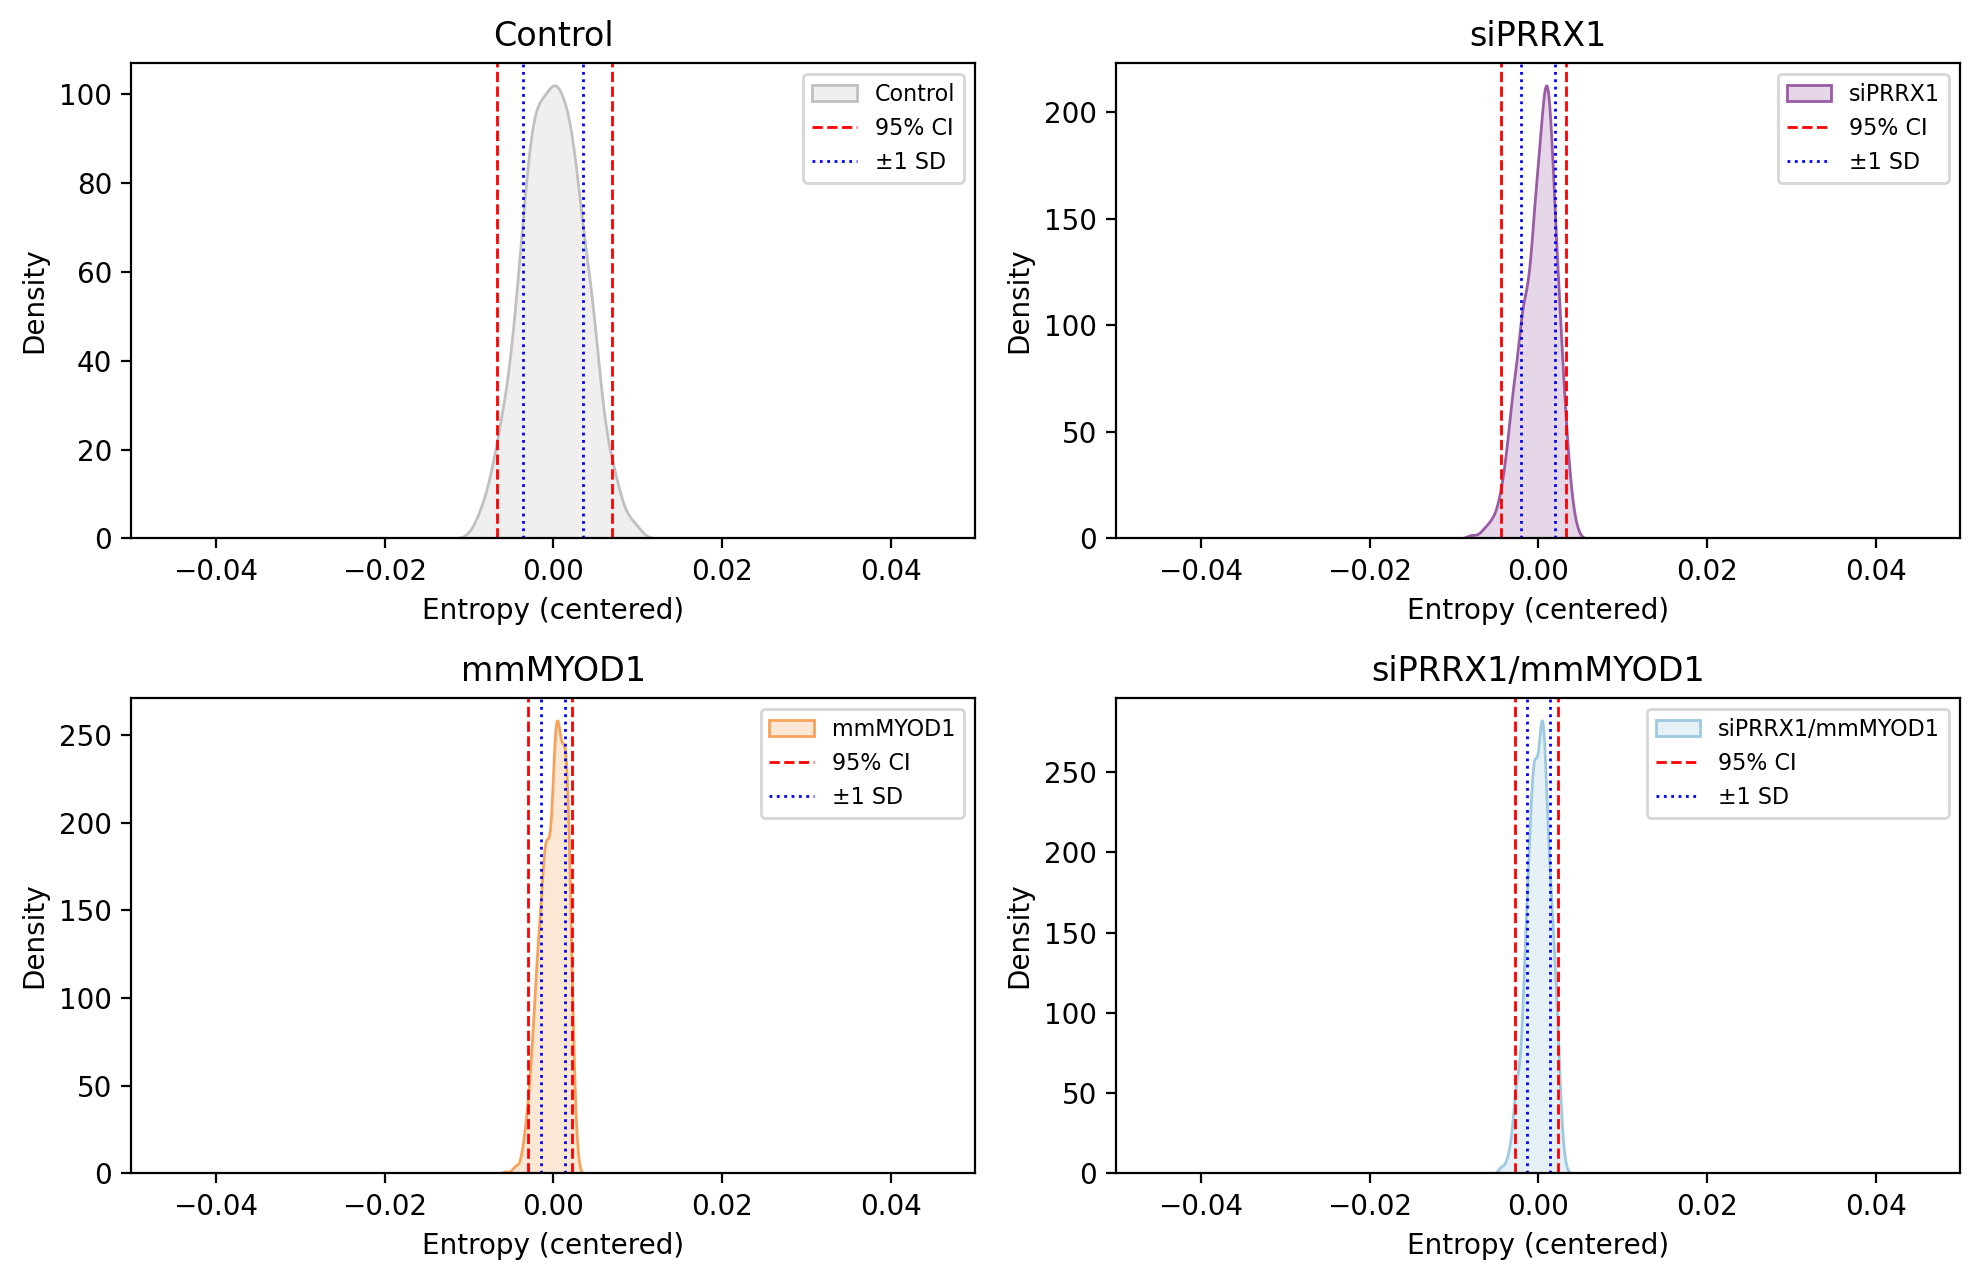

In [122]:
palette = {
    'Control': 'silver',
    'siPRRX1': '#9B5CA6',
    'mmMYOD1': '#F5A35B',
    'siPRRX1/mmMYOD1': '#9ECAE1',
}

fig, axs = plt.subplots(2, 2, figsize=(10, 6.5), dpi=200)
axs = axs.flatten()

for i, cond in enumerate(sdf.columns):
    ax = axs[i]

    centered = sdf[cond] - sdf[cond].mean()
    
    ci_low, ci_high = np.percentile(centered, [2.5, 97.5])
    sd = centered.std()
    
    sns.kdeplot(centered, label=cond, ax=ax, fill=True, color=palette[cond])
    
    ax.axvline(ci_low, c='r', ls='--', lw=1, label='95% CI')
    ax.axvline(ci_high, c='r', ls='--', lw=1)
    
    ax.axvline(-sd, c='b', ls=':', lw=1, label='±1 SD')
    ax.axvline(sd, c='b', ls=':', lw=1)
    
    
    ax.set_xlim([-0.05, 0.05])
    ax.set_xlabel("Entropy (centered)")
    ax.set_title(cond)
    ax.legend(fontsize=8)
    
plt.tight_layout()
plt.show()

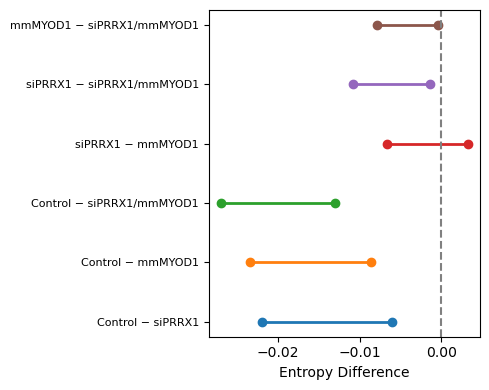

In [123]:
fig, ax = plt.subplots(figsize=(5, 4))
for i, row in results_df.iterrows():
    label = f"{row['condition_1']} − {row['condition_2']}"
    ax.plot([row['ci_low'], row['ci_high']], [i, i], 'o-', lw=2)
    # ax.text(row['ci_high'] + 0.001, i, f"p={row['p_adj']:.3f}", va='center', fontsize=8)
ax.axvline(0, color='gray', linestyle='--')
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels([f"{r['condition_1']} − {r['condition_2']}" for _, r in results_df.iterrows()], fontsize=8)
ax.set_xlabel('Entropy Difference')
plt.tight_layout()

In [124]:
summary = pd.DataFrame({
    'observed': observed_entropy,
    'bootstrap_mean': sdf.mean(),
    'bias': sdf.mean() - observed_entropy,
    'std': sdf.std(),
    'ci_low': sdf.quantile(0.025),
    'ci_high': sdf.quantile(0.975)
})

display(summary.round(4))
# print(summary.round(4))

,observed,bootstrap_mean,bias,std,ci_low,ci_high
Control,0.9720,0.9699,-0.0021,0.0035,0.9632,0.9768
mmMYOD1,0.9872,0.9857,-0.0015,0.0014,0.9828,0.9879
siPRRX1,0.9844,0.9843,-0.0001,0.0020,0.9799,0.9876
siPRRX1/mmMYOD1,0.9911,0.9899,-0.0013,0.0013,0.9871,0.9922


In [125]:
# check bias is okay -- If bias/std < 0.25, then the bias is considered negligible. Thus its safe to proceed with percentile CIs rather than needed BCa correction
summary['bias_check'] = (summary['bias'] * -1) / summary['std']
summary

,observed,bootstrap_mean,bias,std,ci_low,ci_high,bias_check
Control,0.972017,0.969894,-0.002123,0.003530,0.963210,0.976831,0.601356
mmMYOD1,0.987223,0.985749,-0.001474,0.001438,0.982786,0.987925,1.025160
siPRRX1,0.984385,0.984259,-0.000126,0.002042,0.979879,0.987574,0.061675
siPRRX1/mmMYOD1,0.991129,0.989860,-0.001269,0.001345,0.987090,0.992216,0.943502


In [127]:
print(summary.round(4))

                 observed  bootstrap_mean    bias     std  ci_low  ci_high  \
Control            0.9720          0.9699 -0.0021  0.0035  0.9632   0.9768   
mmMYOD1            0.9872          0.9857 -0.0015  0.0014  0.9828   0.9879   
siPRRX1            0.9844          0.9843 -0.0001  0.0020  0.9799   0.9876   
siPRRX1/mmMYOD1    0.9911          0.9899 -0.0013  0.0013  0.9871   0.9922   

                 bias_check  
Control              0.6014  
mmMYOD1              1.0252  
siPRRX1              0.0617  
siPRRX1/mmMYOD1      0.9435  


In [126]:
from scipy.stats import norm

# BCa correction (without acceleration) since bias/SE ratios are high

def bca_ci(observed_val, bootstrap_samples, alpha=0.05):
    """
    observed_val: scalar entropy from full data
    bootstrap_samples: 1D array of bootstrap entropy values
    """
    n_boot = len(bootstrap_samples)
    
    # Bias-correction factor z0
    prop_less = np.mean(bootstrap_samples < observed_val)
    z0 = norm.ppf(prop_less)
    
    # Acceleration factor via jackknife
    # You need to pass in a function to recompute entropy on jackknife samples
    # -- see note below
    
    z_alpha_low = norm.ppf(alpha / 2)
    z_alpha_high = norm.ppf(1 - alpha / 2)
    
    # Adjusted percentiles
    a = 0  # placeholder until jackknife is implemented
    p_low = norm.cdf(z0 + (z0 + z_alpha_low) / (1 - a * (z0 + z_alpha_low)))
    p_high = norm.cdf(z0 + (z0 + z_alpha_high) / (1 - a * (z0 + z_alpha_high)))
    
    ci_low = np.percentile(bootstrap_samples, p_low * 100)
    ci_high = np.percentile(bootstrap_samples, p_high * 100)
    
    return ci_low, ci_high

# Apply per condition
for cond in sdf.columns:
    lo, hi = bca_ci(observed_entropy[cond], sdf[cond].values)
    print(f"{cond}: ({lo:.4f}, {hi:.4f})")

Control: (0.9670, 0.9796)
siPRRX1: (0.9793, 0.9873)
mmMYOD1: (0.9859, 0.9885)
siPRRX1/mmMYOD1: (0.9896, 0.9930)


In [27]:
# shannon
sdf = pd.DataFrame(bootstrap_shannon)
# sdf['iteration'] = sdf.index + 1

print(sdf.shape)
display(sdf.head())


def bootstrap_summary(df):
    """ Computes mean and CIs from bootstrapping """
    summary = []
    
    for cond in condition_order:
        values = df[cond].dropna().values
        
        mean = np.mean(values)
        ci_low, ci_high = np.percentile(values, [2.5, 97.5])
        
        summary.append({
            'condition': cond,
            'mean': mean,
            'CI_lower': ci_low,
            'CI_upper': ci_high,
        })
        
    return pd.DataFrame(summary)


shannon_summary = bootstrap_summary(sdf)
display(shannon_summary)

(1000, 4)


,Control,siPRRX1,mmMYOD1,siPRRX1/mmMYOD1
0,0.670871,0.734003,0.919787,0.925841
1,0.626249,0.729756,0.915507,0.924509
2,0.641352,0.711854,0.918327,0.915783
3,0.670701,0.731675,0.916194,0.934267
4,0.654953,0.729387,0.922482,0.921106


,condition,mean,CI_lower,CI_upper
0,Control,0.659484,0.633611,0.682616
1,siPRRX1,0.726722,0.701988,0.746304
2,mmMYOD1,0.914526,0.903841,0.922546
3,siPRRX1/mmMYOD1,0.921985,0.907832,0.933046


In [31]:
def bootstrap_pairwise_stats(df, control='Control'):
  
    results = []

    for cond1, cond2 in combinations(df.columns, 2):
        x = df[cond1].dropna().values
        y = df[cond2].dropna().values
        
        diff = x - y
        
        mean_diff = np.mean(diff)
        ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
        
        # percent difference (relative to cond2)
        percent_change = (mean_diff / np.mean(y)) * 100
        
        # two-sided p-value
        p_value = 2 * min(
            np.mean(diff >= 0),
            np.mean(diff <= 0)
        )
        
        results.append({
            'Condition_1': cond1,
            'Condition_2': cond2,
            'Mean_Difference': mean_diff,
            'CI_lower_95': ci_low,
            'CI_upper_95': ci_high,
            'Percent_Change_vs_Cond2': percent_change,
            'p_value_raw': p_value
        })

    results_df = pd.DataFrame(results)
    
    reject, pvals_fdr, _, _ = multipletests(
        results_df['p_value_raw'],
        method='fdr_bh'
    )
    
    results_df['p_value_FDR'] = pvals_fdr
    results_df['Significant'] = reject
    
    results_df['p_value_raw'] = results_df['p_value_raw'].apply(lambda x: f"{x:.2e}")
    results_df['p_value_FDR'] = results_df['p_value_FDR'].apply(lambda x: f"{x:.2e}")
    
    return results_df


shannon_pvals = bootstrap_pairwise_stats(sdf)
shannon_pvals

,Condition_1,Condition_2,Mean_Difference,CI_lower_95,CI_upper_95,Percent_Change_vs_Cond2,p_value_raw,p_value_FDR,Significant
0,Control,siPRRX1,-0.067239,-0.102298,-0.032451,-9.252301,0.00e+00,0.00e+00,True
1,Control,mmMYOD1,-0.255042,-0.282184,-0.228753,-27.887907,0.00e+00,0.00e+00,True
2,Control,siPRRX1/mmMYOD1,-0.262501,-0.291583,-0.234626,-28.471292,0.00e+00,0.00e+00,True
3,siPRRX1,mmMYOD1,-0.187804,-0.213871,-0.164164,-20.535624,0.00e+00,0.00e+00,True
4,siPRRX1,siPRRX1/mmMYOD1,-0.195262,-0.220645,-0.170717,-21.178489,0.00e+00,0.00e+00,True
5,mmMYOD1,siPRRX1/mmMYOD1,-0.007459,-0.022863,0.008423,-0.808998,3.10e-01,3.10e-01,False


In [25]:
# def bootstrap_pairwise_stats(df, condition_order=None):
#     """
#     Computes:
#         - Paired bootstrap p-values
#         - FDR correction (BH)
#         - Mean difference
#         - Cohen's d (paired)
#     Returns tidy dataframe.
#     """
    
#     if condition_order is None:
#         condition_order = df.columns.tolist()
    
#     results = []

#     for cond1, cond2 in combinations(condition_order, 2):
#         x = df[cond1].dropna().values
#         y = df[cond2].dropna().values
        
#         # Paired difference
#         diff = x - y
        
#         # Two-sided bootstrap p-value
#         p_value = 2 * min(
#             np.mean(diff >= 0),
#             np.mean(diff <= 0)
#         )
        
#         # Paired Cohen's d
#         mean_diff = np.mean(diff)
#         sd_diff   = np.std(diff, ddof=1)
#         cohens_d  = mean_diff / sd_diff if sd_diff != 0 else np.nan
        
#         # percent difference (relative to cond2)
#         percent_change = (mean_diff / np.mean(y)) * 100
        
#         results.append({
#             'Condition_1': cond1,
#             'Condition_2': cond2,
#             'Mean_Difference': mean_diff,
#             'Cohens_d': cohens_d,
#             'p_value_raw': p_value
#         })
    
#     results_df = pd.DataFrame(results)
    
#     # FDR correction
#     reject, pvals_fdr, _, _ = multipletests(
#         results_df['p_value_raw'],
#         method='fdr_bh'
#     )
    
#     results_df['p_value_FDR'] = pvals_fdr
#     results_df['Significant'] = reject
    
#     # Scientific notation formatting
#     results_df['p_value_raw'] = results_df['p_value_raw'].apply(lambda x: f"{x:.2e}")
#     results_df['p_value_FDR'] = results_df['p_value_FDR'].apply(lambda x: f"{x:.2e}")
    
#     return results_df



# shannon_pvals = bootstrap_pairwise_stats(sdf)
# shannon_pvals

,Condition_1,Condition_2,Mean_Difference,Cohens_d,p_value_raw,p_value_FDR,Significant
0,Control,siPRRX1,-0.067239,-3.847693,0.00e+00,0.00e+00,True
1,Control,mmMYOD1,-0.255042,-18.680378,0.00e+00,0.00e+00,True
2,Control,siPRRX1/mmMYOD1,-0.262501,-17.901003,0.00e+00,0.00e+00,True
3,siPRRX1,mmMYOD1,-0.187804,-14.795569,0.00e+00,0.00e+00,True
4,siPRRX1,siPRRX1/mmMYOD1,-0.195262,-14.856159,0.00e+00,0.00e+00,True
5,mmMYOD1,siPRRX1/mmMYOD1,-0.007459,-0.948125,3.10e-01,3.10e-01,False


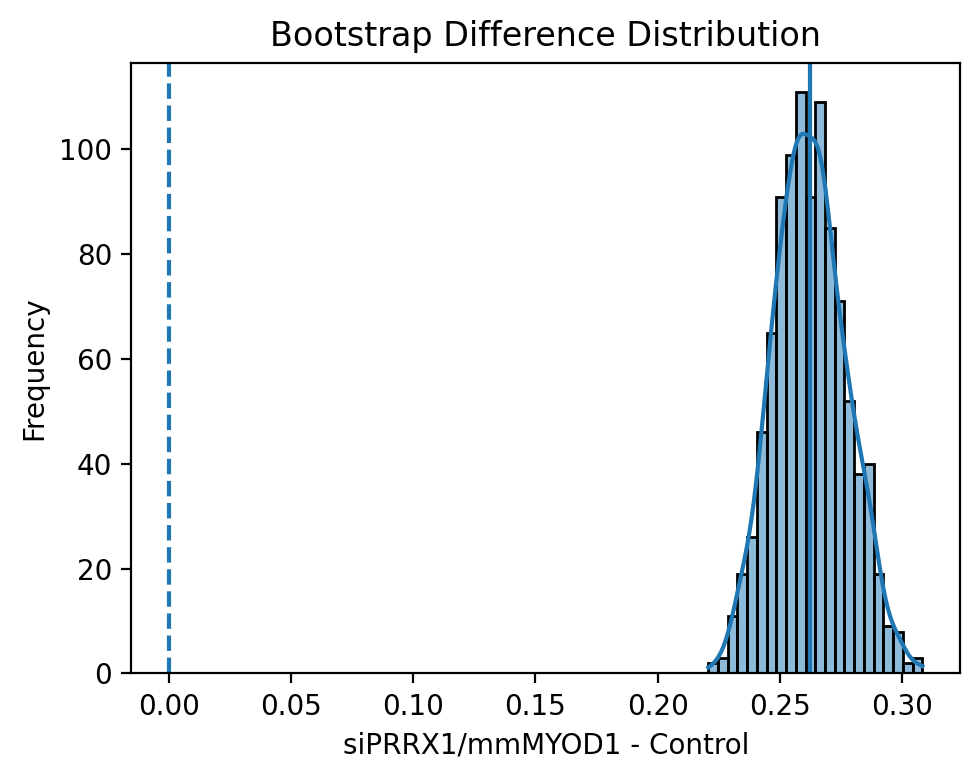

In [26]:
def plot_bootstrap_differences(df, cond1, cond2):
    diff = df[cond1] - df[cond2]
    
    plt.figure(figsize=(5,4), dpi=200)
    sns.histplot(diff, kde=True)
    
    plt.axvline(0, linestyle='--')
    plt.axvline(np.mean(diff))
    
    plt.xlabel(f"{cond1} - {cond2}")
    plt.ylabel("Frequency")
    plt.title("Bootstrap Difference Distribution")
    plt.tight_layout()
    plt.show()
    
plot_bootstrap_differences(sdf, 'siPRRX1/mmMYOD1', 'Control')

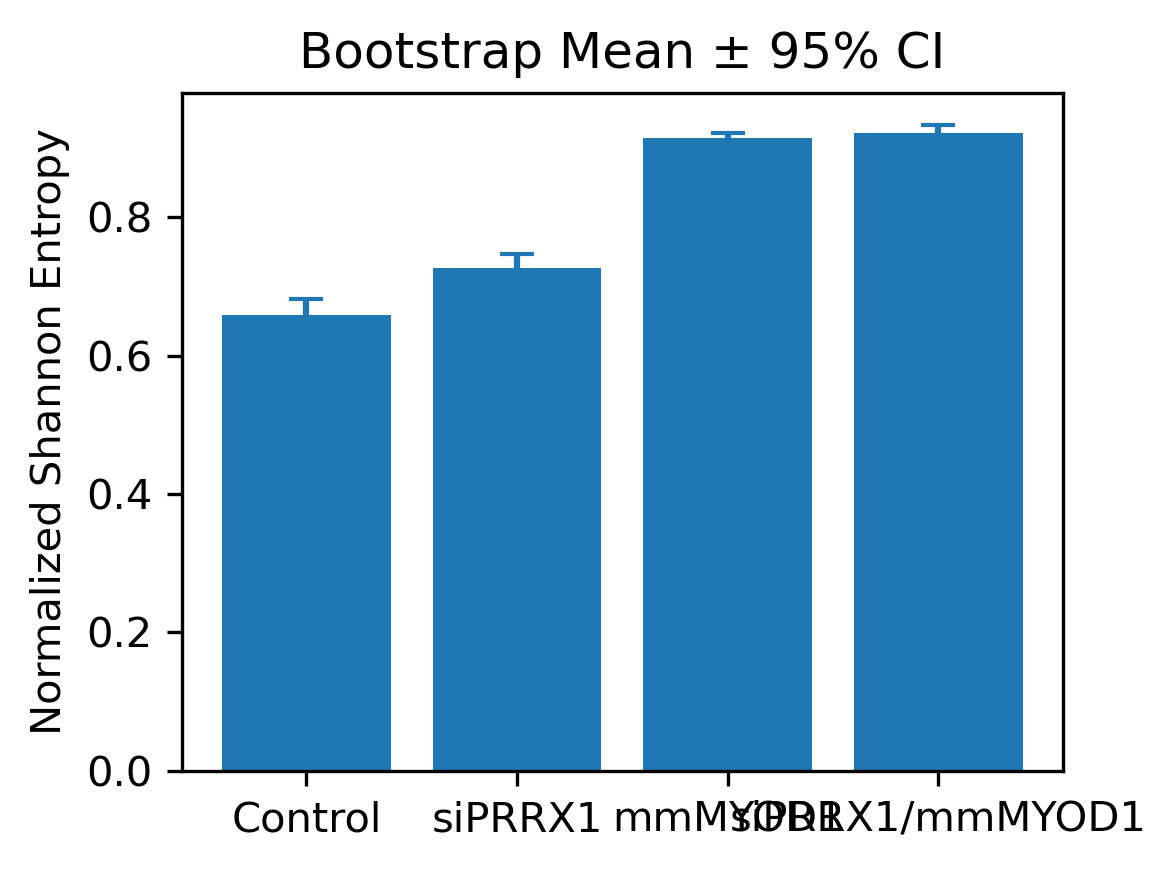

In [30]:
plt.figure(figsize=(4,3), dpi=300)

plt.bar(
    shannon_summary['condition'],
    shannon_summary['mean']
)

# Add CI error bars
plt.errorbar(
    shannon_summary['condition'],
    shannon_summary['mean'],
    yerr=[
        shannon_summary['mean'] - shannon_summary['CI_lower'],
        shannon_summary['CI_upper'] - shannon_summary['mean']
    ],
    fmt='none',
    capsize=4
)

plt.ylabel("Entropy")
plt.title("Bootstrap Mean ± 95% CI")
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# def bootstrap_difference_vs_control(df, control='Control'):
#     results = []

#     for cond in df.columns:
#         if cond == control:
#             continue

#         diff = df[cond] - df[control]

#         mean_diff = np.mean(diff)
#         ci_low, ci_high = np.percentile(diff, [2.5, 97.5])

#         # two-sided paired bootstrap p-value
#         p_value = 2 * min(
#             np.mean(diff >= 0),
#             np.mean(diff <= 0)
#         )

#         results.append({
#             'Condition': cond,
#             'Mean_Difference_vs_Control': mean_diff,
#             'CI_lower_95': ci_low,
#             'CI_upper_95': ci_high,
#             'p_value': p_value
#         })

#     results_df = pd.DataFrame(results)

#     return results_df
def bootstrap_difference_vs_control(df, control='Control'):
    
    results = []
    B = df.shape[0]  # number of bootstrap iterations
    
    for cond in df.columns:
        if cond == control:
            continue

        diff = df[cond] - df[control]

        mean_diff = np.mean(diff)
        ci_low, ci_high = np.percentile(diff, [2.5, 97.5])

        # Count extreme values
        n_ge_0 = np.sum(diff >= 0)
        n_le_0 = np.sum(diff <= 0)

        # Proper bootstrap p-value with +1 correction
        p_value = 2 * min(
            (n_ge_0 + 1) / (B + 1),
            (n_le_0 + 1) / (B + 1)
        )

        results.append({
            'Condition': cond,
            'Mean_Difference_vs_Control': mean_diff,
            'CI_lower_95': ci_low,
            'CI_upper_95': ci_high,
            'p_value_raw': p_value
        })

    results_df = pd.DataFrame(results)

    # FDR correction
    reject, pvals_fdr, _, _ = multipletests(
        results_df['p_value_raw'],
        method='fdr_bh'
    )

    results_df['p_value_FDR'] = pvals_fdr
    results_df['Significant'] = reject

    return results_df



sdf1 = bootstrap_difference_vs_control(sdf)
sdf1

,Condition,Mean_Difference_vs_Control,CI_lower_95,CI_upper_95,p_value_raw,p_value_FDR,Significant
0,siPRRX1,0.067239,0.032451,0.102298,0.001998,0.001998,True
1,mmMYOD1,0.255042,0.228753,0.282184,0.001998,0.001998,True
2,siPRRX1/mmMYOD1,0.262501,0.234626,0.291583,0.001998,0.001998,True


In [33]:
def bootstrap_synergy_test(df,
                            control='Control',
                            condA='siPRRX1',
                            condB='mmMYOD1',
                            combo='siPRRX1/mmMYOD1'):
    
    synergy = (
        df[combo]
        - (df[condA] + df[condB] - df[control])
    )

    mean_synergy = np.mean(synergy)
    ci_low, ci_high = np.percentile(synergy, [2.5, 97.5])

    # one-sided test (is synergy > 0?)
    p_value = np.mean(synergy <= 0)

    return pd.DataFrame({
        'Mean_Synergy': [mean_synergy],
        'CI_lower_95': [ci_low],
        'CI_upper_95': [ci_high],
        'p_value_one_sided': [p_value]
    })

syndf = bootstrap_synergy_test(sdf)
syndf

,Mean_Synergy,CI_lower_95,CI_upper_95,p_value_one_sided
0,-0.05978,-0.097289,-0.024394,0.999


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


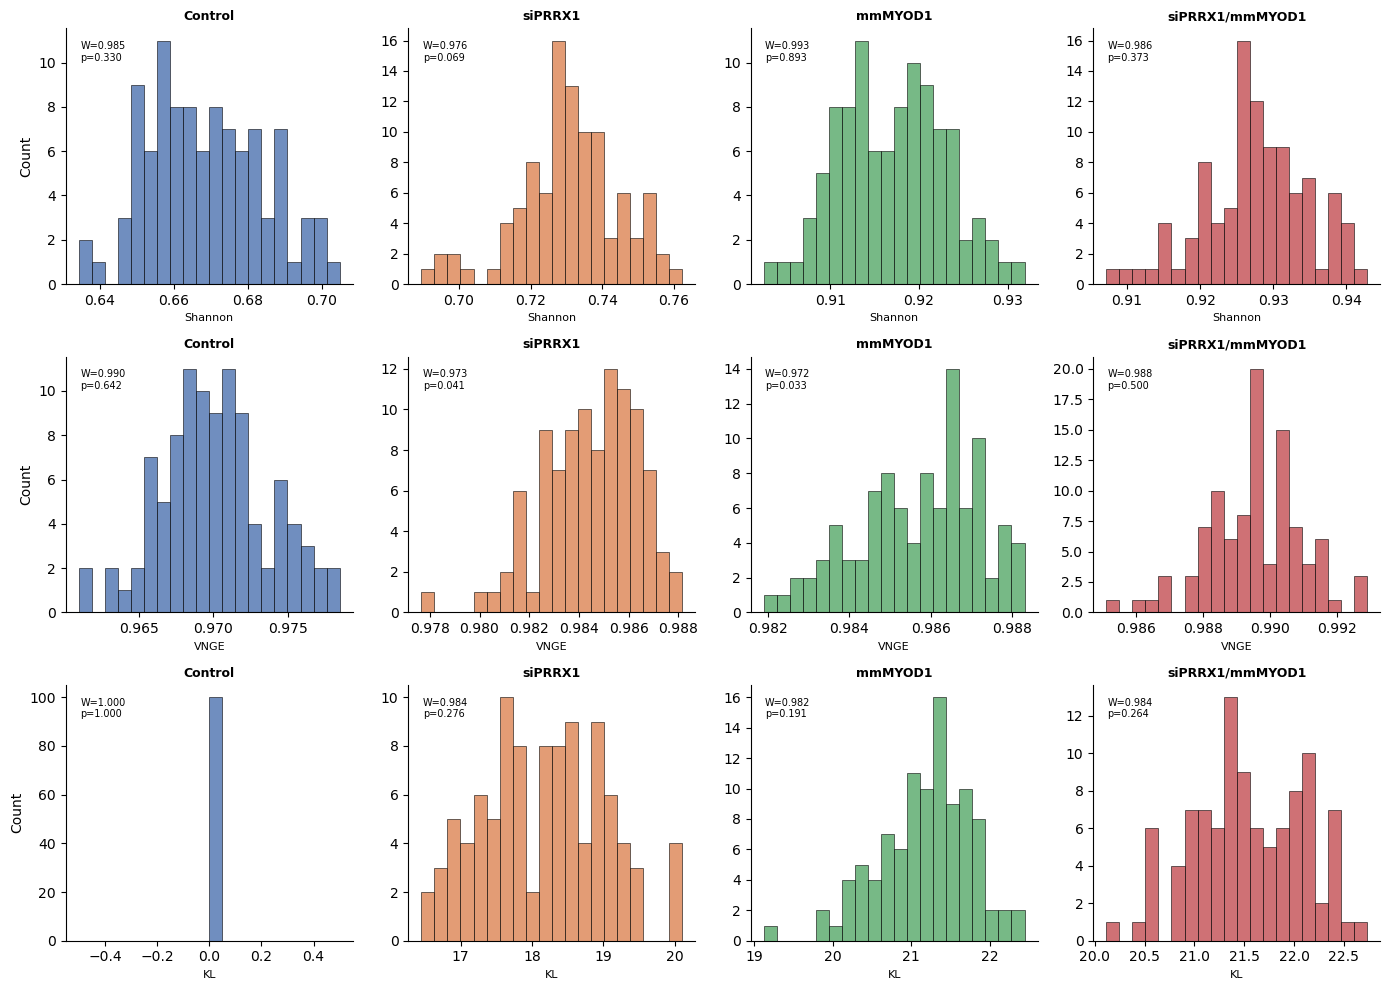

In [31]:
# from scipy.stats import shapiro

# fig, axes = plt.subplots(3, len(condition_order), figsize=(14, 10))

# for row, (metric_name, data) in enumerate([('Shannon', bootstrap_shannon), ('VNGE', bootstrap_vnge), ('KL', bootstrap_kl)]):
#     for col, cond in enumerate(condition_order):
#         ax = axes[row, col]
#         vals = np.array(data[cond])
        
#         ax.hist(vals, bins=20, color=colors[col], edgecolor='black', linewidth=0.5, alpha=0.8)
#         ax.set_title(f'{cond}', fontsize=9, fontweight='bold')
#         ax.set_xlabel(metric_name, fontsize=8)
#         ax.set_ylabel('Count' if col == 0 else '')
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)
        
#         # Shapiro-Wilk test for normality
#         stat, p = shapiro(vals)
#         ax.text(0.05, 0.95, f'W={stat:.3f}\np={p:.3f}', transform=ax.transAxes,
#                 fontsize=7, verticalalignment='top')

# plt.tight_layout()
# plt.show()

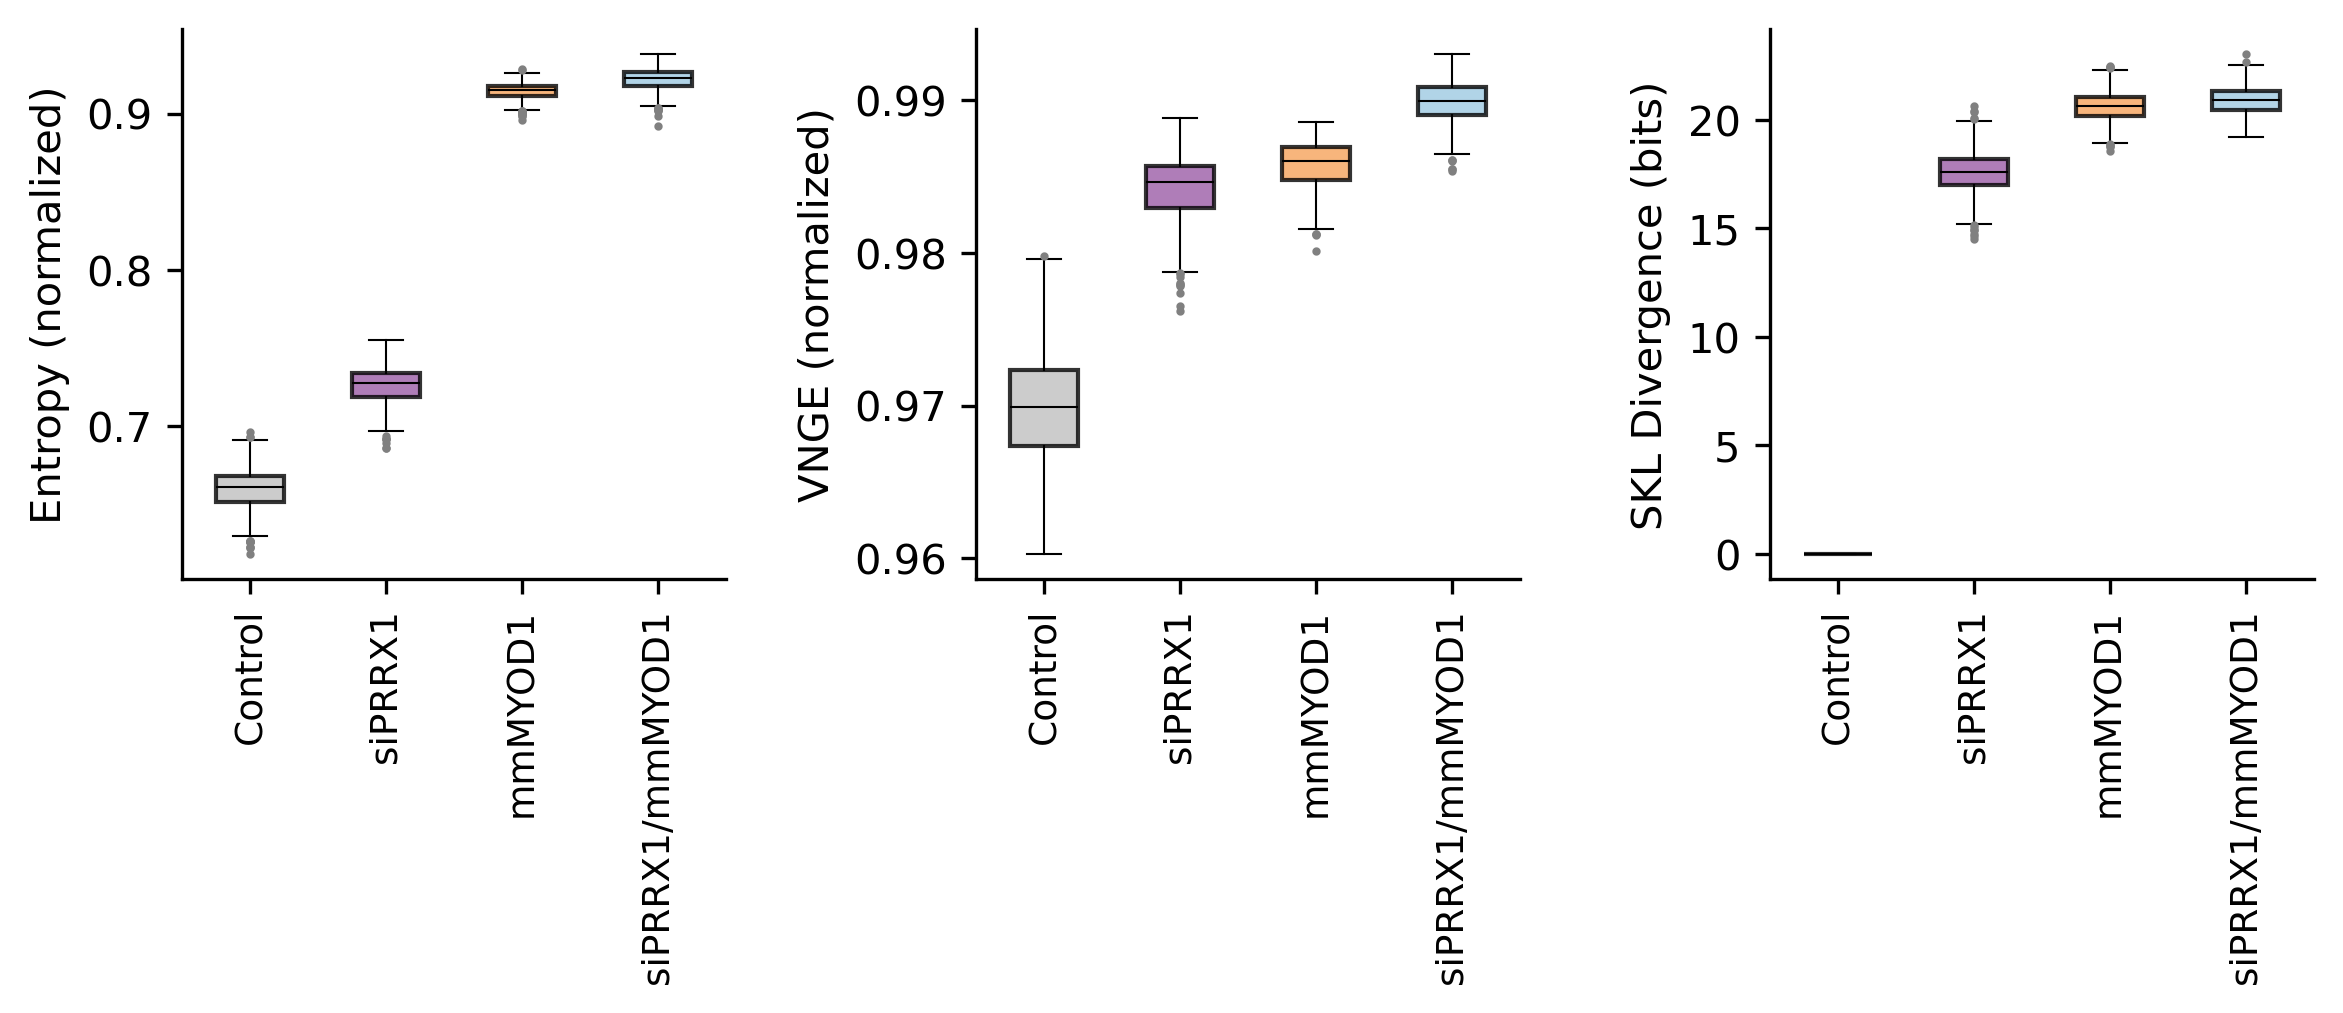

In [102]:
# --- 6. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(8, 3.5), dpi=300)
# colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
colors = ['silver', '#9B5CA6', '#F5A35B', '#9ECAE1']

          
plot_data = [
    (bootstrap_shannon, 'Normalized Shannon Entropy', 'Entropy (normalized)'),
    (bootstrap_vnge,    'Normalized VNGE',            'VNGE (normalized)'),
    (bootstrap_kl,      'SKL Divergence vs. Control', 'SKL Divergence (bits)'),
]

for ax, (data, title, ylabel) in zip(axes, plot_data):
    bp = ax.boxplot(
        [data[c] for c in condition_order],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=0.5),
        whiskerprops=dict(linewidth=0.5),
        capprops=dict(linewidth=0.5),
        flierprops=dict(marker='o', markersize=1, linestyle='none', markeredgecolor='gray'),
        widths=0.5
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(1, len(condition_order) + 1))
    ax.set_xticklabels(condition_order, rotation=90, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
# --- 7. Mann-Whitney U tests vs Control ---
print("\n=== Mann-Whitney U tests vs Control ===")
for metric_name, data in [('Shannon', bootstrap_shannon), ('VNGE', bootstrap_vnge), ('KL', bootstrap_kl)]:
    print(f"\n{metric_name}:")
    for cond in condition_order:
        if cond == 'Control':
            continue
        stat, p = mannwhitneyu(data['Control'], data[cond], alternative='two-sided')
        print(f"  Control vs {cond}: p = {p:.8f}")


=== Mann-Whitney U tests vs Control ===

Shannon:
  Control vs siPRRX1: p = 0.00000000
  Control vs mmMYOD1: p = 0.00000000
  Control vs siPRRX1/mmMYOD1: p = 0.00000000

VNGE:
  Control vs siPRRX1: p = 0.00000000
  Control vs mmMYOD1: p = 0.00000000
  Control vs siPRRX1/mmMYOD1: p = 0.00000000

KL:
  Control vs siPRRX1: p = 0.00000000
  Control vs mmMYOD1: p = 0.00000000
  Control vs siPRRX1/mmMYOD1: p = 0.00000000


In [48]:
# results = []
# for metric_name, data in [('Shannon', bootstrap_shannon), ('VNGE', bootstrap_vnge), ('KL', bootstrap_kl)]:
#     for cond in condition_order:
#         if cond == 'Control':
#             continue
#         x = np.array(data['Control'])
#         y = np.array(data[cond])
#         stat, p = mannwhitneyu(x, y, alternative='two-sided')
#         n1, n2 = len(x), len(y)
#         r = 1 - (2 * stat) / (n1 * n2)
#         results.append({'metric': metric_name, 'condition': cond, 'U': stat, 'p': p, 'r': r})

# results_df = pd.DataFrame(results)

# # Apply BH correction across all tests
# reject, p_adj, _, _ = multipletests(results_df['p'], method='fdr_bh')
# results_df['p_adj'] = p_adj
# results_df['reject_H0'] = reject

# display(results_df)

,metric,condition,U,p,r,p_adj,reject_H0
0,Shannon,siPRRX1,898.0,0.0,0.998204,0.0,True
1,Shannon,mmMYOD1,0.0,0.0,1.000000,0.0,True
2,Shannon,siPRRX1/mmMYOD1,0.0,0.0,1.000000,0.0,True
3,VNGE,siPRRX1,151.0,0.0,0.999698,0.0,True
4,VNGE,mmMYOD1,2.0,0.0,0.999996,0.0,True
5,VNGE,siPRRX1/mmMYOD1,0.0,0.0,1.000000,0.0,True
6,KL,siPRRX1,0.0,0.0,1.000000,0.0,True
7,KL,mmMYOD1,0.0,0.0,1.000000,0.0,True
8,KL,siPRRX1/mmMYOD1,0.0,0.0,1.000000,0.0,True
